# 0. Setup & Imports

In [1]:
# Data comes from `cmapss_db.py`, which picks its source automatically:
#   * Neon Postgres  when DATABASE_URL is set (see README -> Run the Project)
#   * CMaps/*.txt    otherwise, so a fresh clone or a Binder session just works
# Both paths return identical frames, so results do not depend on the source.
#
# Colab: upload cmapss_db.py and the CMaps/ folder next to this notebook, then
# uncomment the line below.
# !pip install -q tensorflow-cpu xgboost seaborn


In [2]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import lag_plot

# Reproducibility — every model in section 5 is seeded from this constant.
# Without it the four Keras models re-initialise differently on every run and
# the comparison table in section 6 cannot be reproduced.
SEED = 42
np.random.seed(SEED)


# 1. Data Loading

In [3]:
# Load FD001. This replaces the old file paths *and* the RUL label generation
# that used to live in section 2 below.
import cmapss_db as db

print(f"Reading from {db.source_description()}")
df_train, df_test, df_RUL = db.load_notebook_frames("FD001")

# Frames match the previous file-based versions column for column:
#   df_train / df_test = 26 data columns + RUL_Max + RUL
#   df_train.RUL_Max   = that engine's final cycle (training runs to failure)
#   df_test.RUL_Max    = ground-truth RUL at the last observed cycle (y_test)
#   RUL                = RUL_Max - time_in_cycles
#   df_RUL             = raw ground-truth table (Y, unit_number)
print(df_train.shape, df_test.shape, df_RUL.shape)


Reading from Neon Postgres (schema `cmapss`)


(20631, 28) (13096, 28) (100, 2)


In [4]:
df_train.head()

,unit_number,time_in_cycles,setting_1,setting_2,TRA,T2,T24,T30,T50,P2,...,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32,RUL_Max,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392.0,2388.0,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392.0,2388.0,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390.0,2388.0,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392.0,2388.0,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393.0,2388.0,100.0,38.90,23.4044,192,187


In [5]:
df_test.head()

,unit_number,time_in_cycles,setting_1,setting_2,TRA,T2,T24,T30,T50,P2,...,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32,RUL_Max,RUL
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,8125.55,8.4052,0.03,392.0,2388.0,100.0,38.86,23.3735,112,111
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,8139.62,8.3803,0.03,393.0,2388.0,100.0,39.02,23.3916,112,110
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,8130.10,8.4441,0.03,393.0,2388.0,100.0,39.08,23.4166,112,109
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,8132.90,8.3917,0.03,391.0,2388.0,100.0,39.00,23.3737,112,108
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,8129.54,8.4031,0.03,390.0,2388.0,100.0,38.99,23.4130,112,107


In [6]:
df_RUL.head()

,Y,unit_number
0,112,1
1,98,2
2,69,3
3,82,4
4,91,5


# 2. RUL Label Generation

In [7]:
# RUL labels are generated inside db.load_notebook_frames():
#   train: RUL_Max = max cycle per engine, RUL = RUL_Max - time_in_cycles
#   test:  RUL_Max = ground-truth Y,       RUL = RUL_Max - time_in_cycles
df_train[['unit_number', 'time_in_cycles', 'RUL_Max', 'RUL']].head()


,unit_number,time_in_cycles,RUL_Max,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187


# 3. EDA

## 3.1 Correlation Matrix

In [8]:
# Remove constant columns (std < 1e-10) — appear as blank in heatmap
constant_cols = [col for col in df_train.columns if df_train[col].std() < 1e-10]
print("Constant columns dropped:", constant_cols)

df_train_clean = df_train.drop(columns=constant_cols)
df_test_clean  = df_test.drop(columns=constant_cols)

Constant columns dropped: ['TRA', 'T2', 'P2', 'epr', 'farB', 'Nf_dmd', 'PCNfR_dmd']


`TRA`, `Nf_dmd`, `PCNfR_dmd`, `farB`, `epr`, `P2`, `T2` were excluded
due to near-zero variance, as they carry no discriminative information.

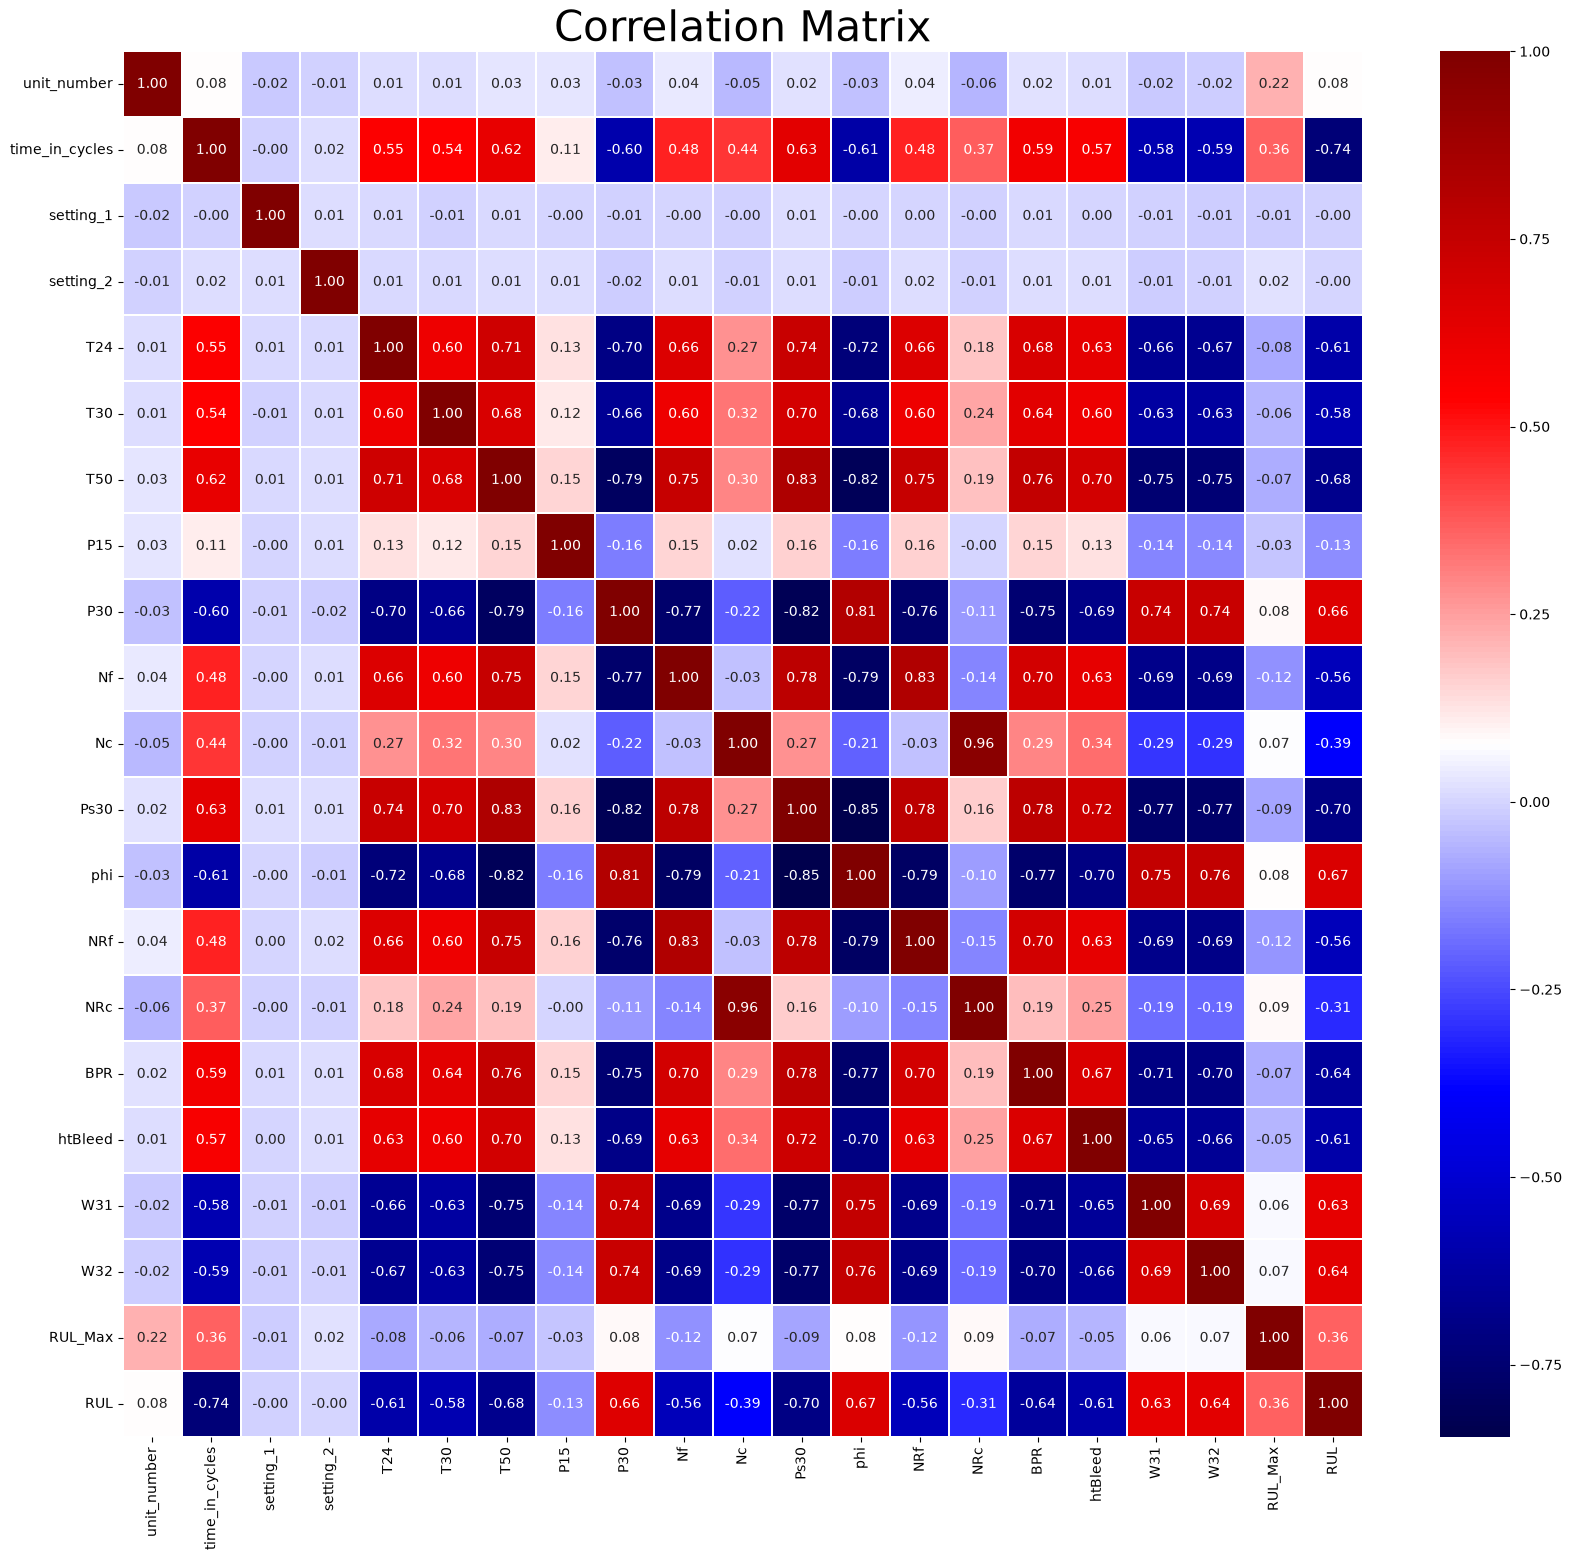

In [9]:
# Correlation matrix after removing constant columns
plt.figure(figsize=(20, 18))
sns.heatmap(df_train_clean.corr(), annot=True, cmap='seismic', fmt=".2f", linewidths=0.2)
plt.title('Correlation Matrix', fontsize=30)
plt.show()

**Feature Descriptions:**

| Column | Description |
|--------|-------------|
| unit_number | Engine ID |
| time_in_cycles | Operational cycle count |
| setting_1 | Operational setting 1 |
| setting_2 | Operational setting 2 |
| T24 | Total temperature at LPC outlet |
| T30 | Total temperature at HPC outlet |
| T50 | Total temperature at LPT outlet |
| P15 | Total pressure in bypass-duct |
| P30 | Total pressure at HPC outlet |
| Nf | Physical fan speed |
| Nc | Physical core speed |
| Ps30 | Static pressure at HPC outlet |
| phi | Ratio of fuel flow to Ps30 |
| NRf | Corrected fan speed |
| NRc | Corrected core speed |
| BPR | Bypass ratio |
| htBleed | Bleed enthalpy |
| W31 | HPT coolant bleed |
| W32 | LPT coolant bleed |
| RUL_Max | Total cycles until failure |
| RUL | Remaining useful life (target) |

**Engine components referenced in sensor names**

Air flows through a turbofan engine in this order: fan → LPC → HPC → combustor → HPT → LPT → exhaust.

- **Fan** — the large front blades; pulls air in. Sensors: `Nf`, `NRf` (fan speed)
- **LPC** (low-pressure compressor) — first stage of squeezing the air. Sensor: `T24` (LPC outlet temp)
- **HPC** (high-pressure compressor) — squeezes the air much harder before it enters the combustor. Sensors: `T30`, `P30`, `Ps30` (HPC outlet temp / pressures)
- **HPT** (high-pressure turbine) — spins the HPC using hot exhaust. Sensor: `W31` (HPT cooling air)
- **LPT** (low-pressure turbine) — spins the fan and LPC. Sensors: `T50` (LPT outlet temp), `W32` (LPT cooling air)
- **Core** — the HPC + HPT shaft. Sensors: `Nc`, `NRc` (core speed)

**Key Observations:**
- `time_in_cycles` shows strong negative correlation with RUL (-0.74),
  confirming degradation progresses over time
- `Ps30`, `phi`, `P30`, `W31`, `W32` are among the strongest RUL-correlated sensors (|r| > 0.6), suggesting pressure/flow changes reflect engine wear
- `Nc` ↔ `NRc` (0.96), `Nf` ↔ `NRf` (0.83), `W31` ↔ `W32` (0.69) show high multicollinearity, indicating redundant features to address in preprocessing

## 3.2 Sensor Degradation Analysis

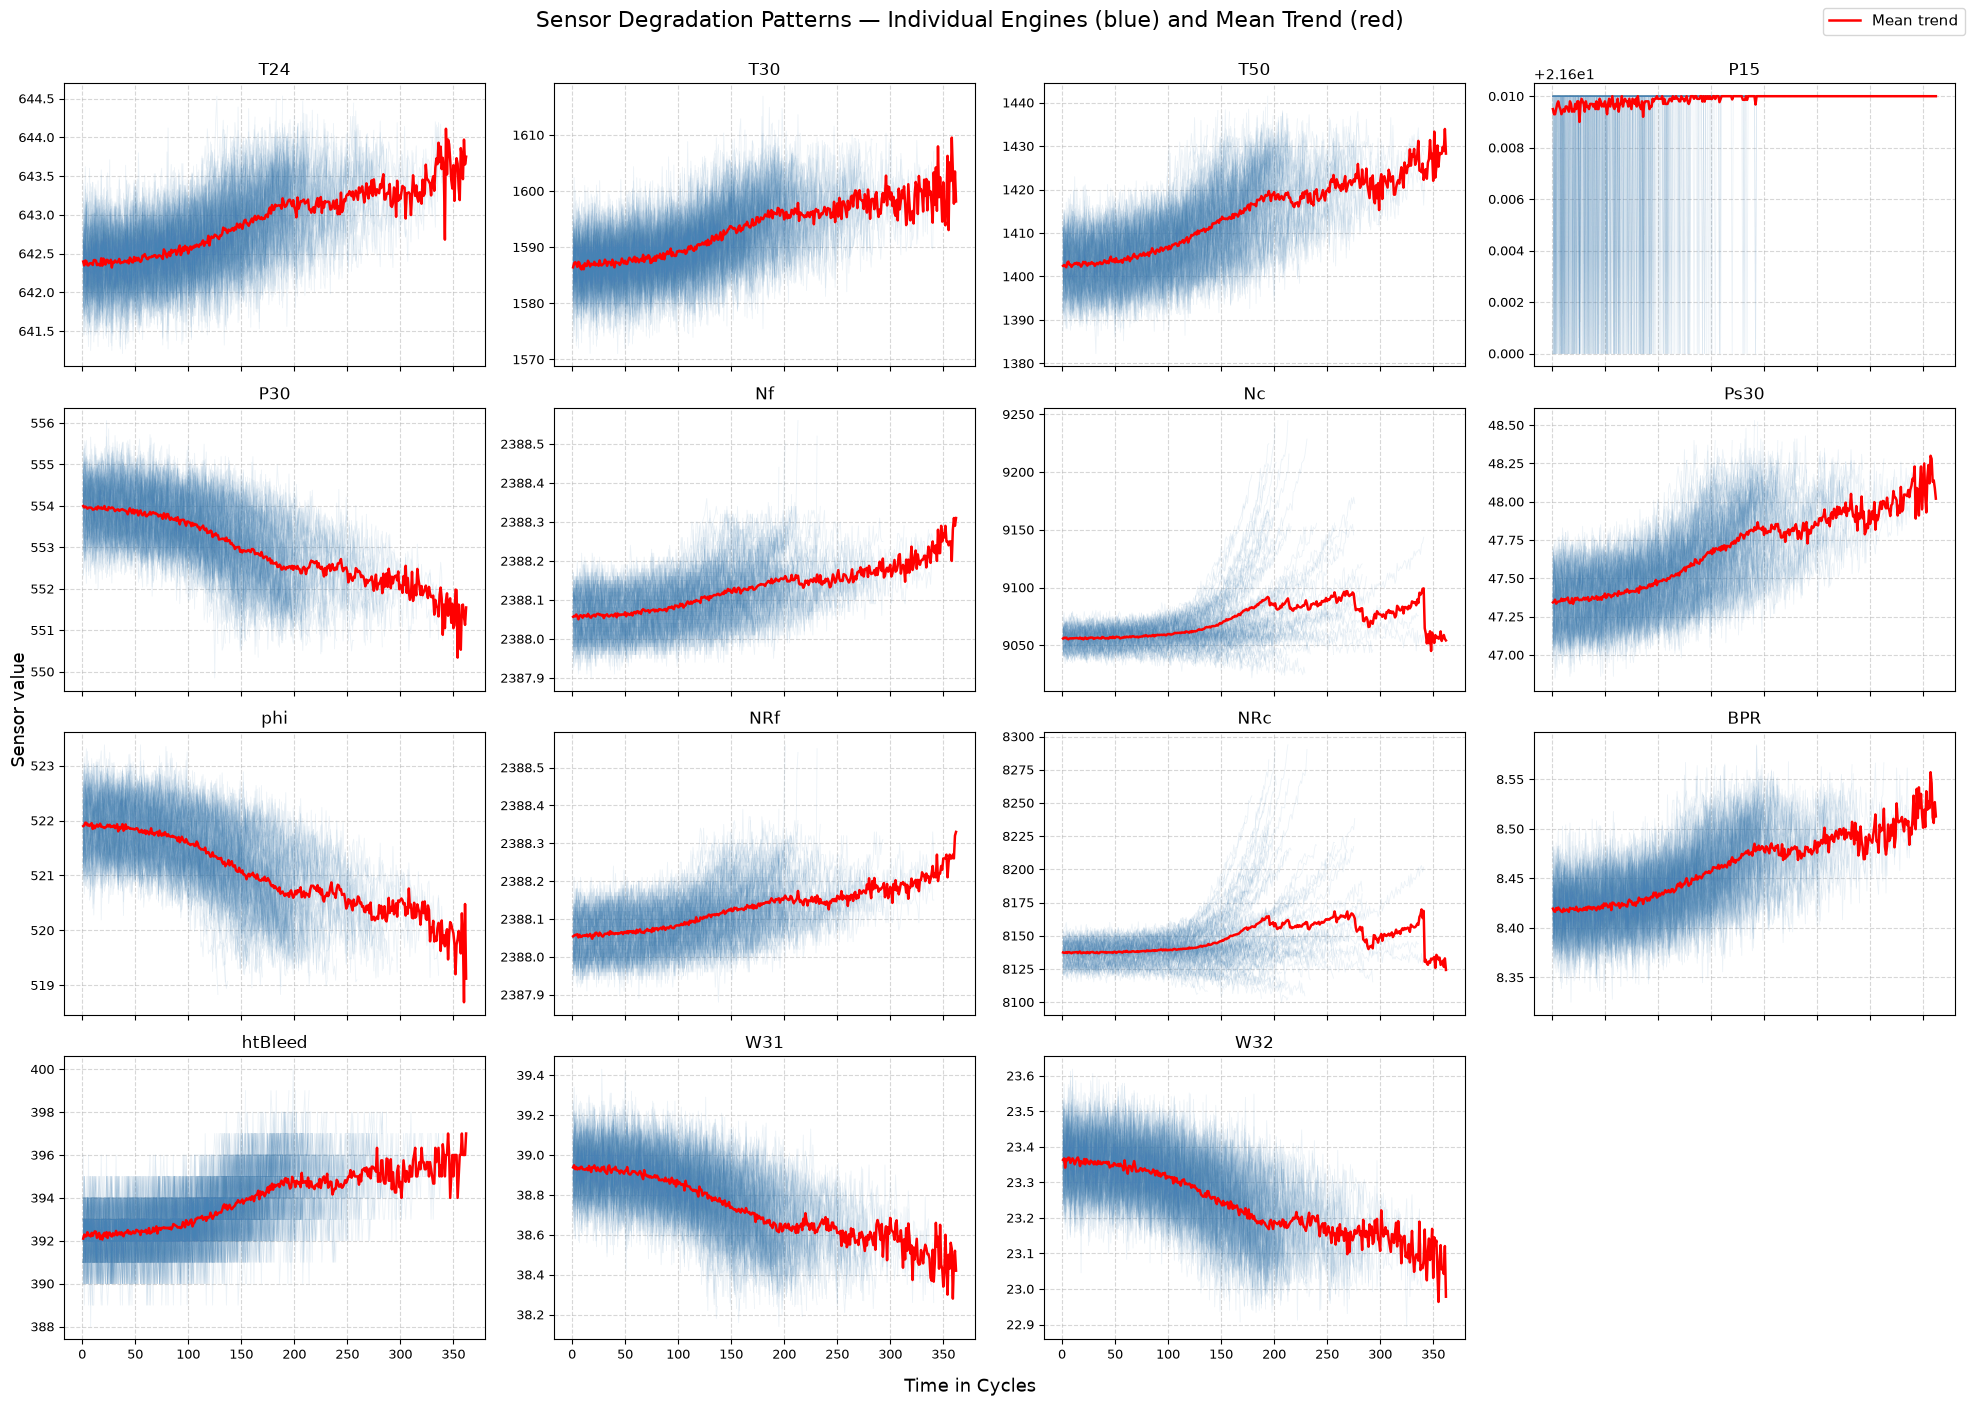

In [10]:
import math

# All sensor columns — exclude index, settings, and target variables
exclude = ['unit_number', 'time_in_cycles', 'RUL_Max', 'RUL', 'setting_1', 'setting_2']
features = [col for col in df_train_clean.columns if col not in exclude]

# Grid layout: 4 columns → 12 sensors = 3x4, 10 sensors = 3x4 with 2 empty panels
ncols = 4
nrows = math.ceil(len(features) / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 3.5 * nrows),
    sharex=True          # X (cycles) is shared; Y is per-sensor since scales differ
)
axes = axes.flatten()

# Pre-compute once instead of filtering inside every subplot loop
unit_groups = list(df_train_clean.groupby('unit_number'))            # per-engine trajectories
trends = df_train_clean.groupby('time_in_cycles')[features].mean()   # mean across engines per cycle

for ax, feature in zip(axes, features):
    # Individual engine lines — single color, high transparency
    for _, unit_data in unit_groups:
        ax.plot(unit_data['time_in_cycles'], unit_data[feature],
                color='steelblue', alpha=0.1, linewidth=0.6)

    # Mean trend line across all engines
    ax.plot(trends.index, trends[feature],
            color='red', linewidth=1.8, label='Mean trend')

    ax.set_title(feature, fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(labelsize=9)

# Hide unused axes when the sensor count doesn't fill the grid
for ax in axes[len(features):]:
    ax.set_visible(False)

# One shared legend + shared axis labels instead of repeating on every panel
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=11)
fig.supxlabel('Time in Cycles', fontsize=13)
fig.supylabel('Sensor value', fontsize=13)
fig.suptitle('Sensor Degradation Patterns — Individual Engines (blue) and Mean Trend (red)',
             fontsize=16, y=1.0)

plt.tight_layout()
plt.show()

**Sensor Degradation Analysis:**

Retained — clear, one-directional trends over cycles:
- Rising: `T24`, `T30`, `T50` (temperatures), `Ps30` (pressure), `BPR` (air-flow ratio), `htBleed` (bleed air)
- Falling: `P30` (pressure), `phi` (fuel flow), `W31`, `W32` (cooling air)
- Slightly rising: `Nf`, `NRf` (fan speed) — small but consistent

Removed by visual inspection:
- `P15` (pressure) — effectively constant (21.60–21.61)
- `Nc`, `NRc` (core speed) — flat until ~cycle 200, then unstable; near-duplicates (r = 0.96)

**Key Takeaways:**
- As an engine wears out, its temperatures rise while pressures and fuel flow fall — and these shifts are visible in the sensors.
- This matches how the dataset was built: it simulates gradual compressor wear, and a less efficient compressor pushes downstream temperatures up and pressures down.
- 7 zero-variance columns + 3 sensors (P15, Nc, NRc) removed; 12 sensors retained.
- So what: the retained sensors carry a usable time trend → supports a sequence model, and their very different scales → require scaling before modeling.

## 3.3 Stationarity Check

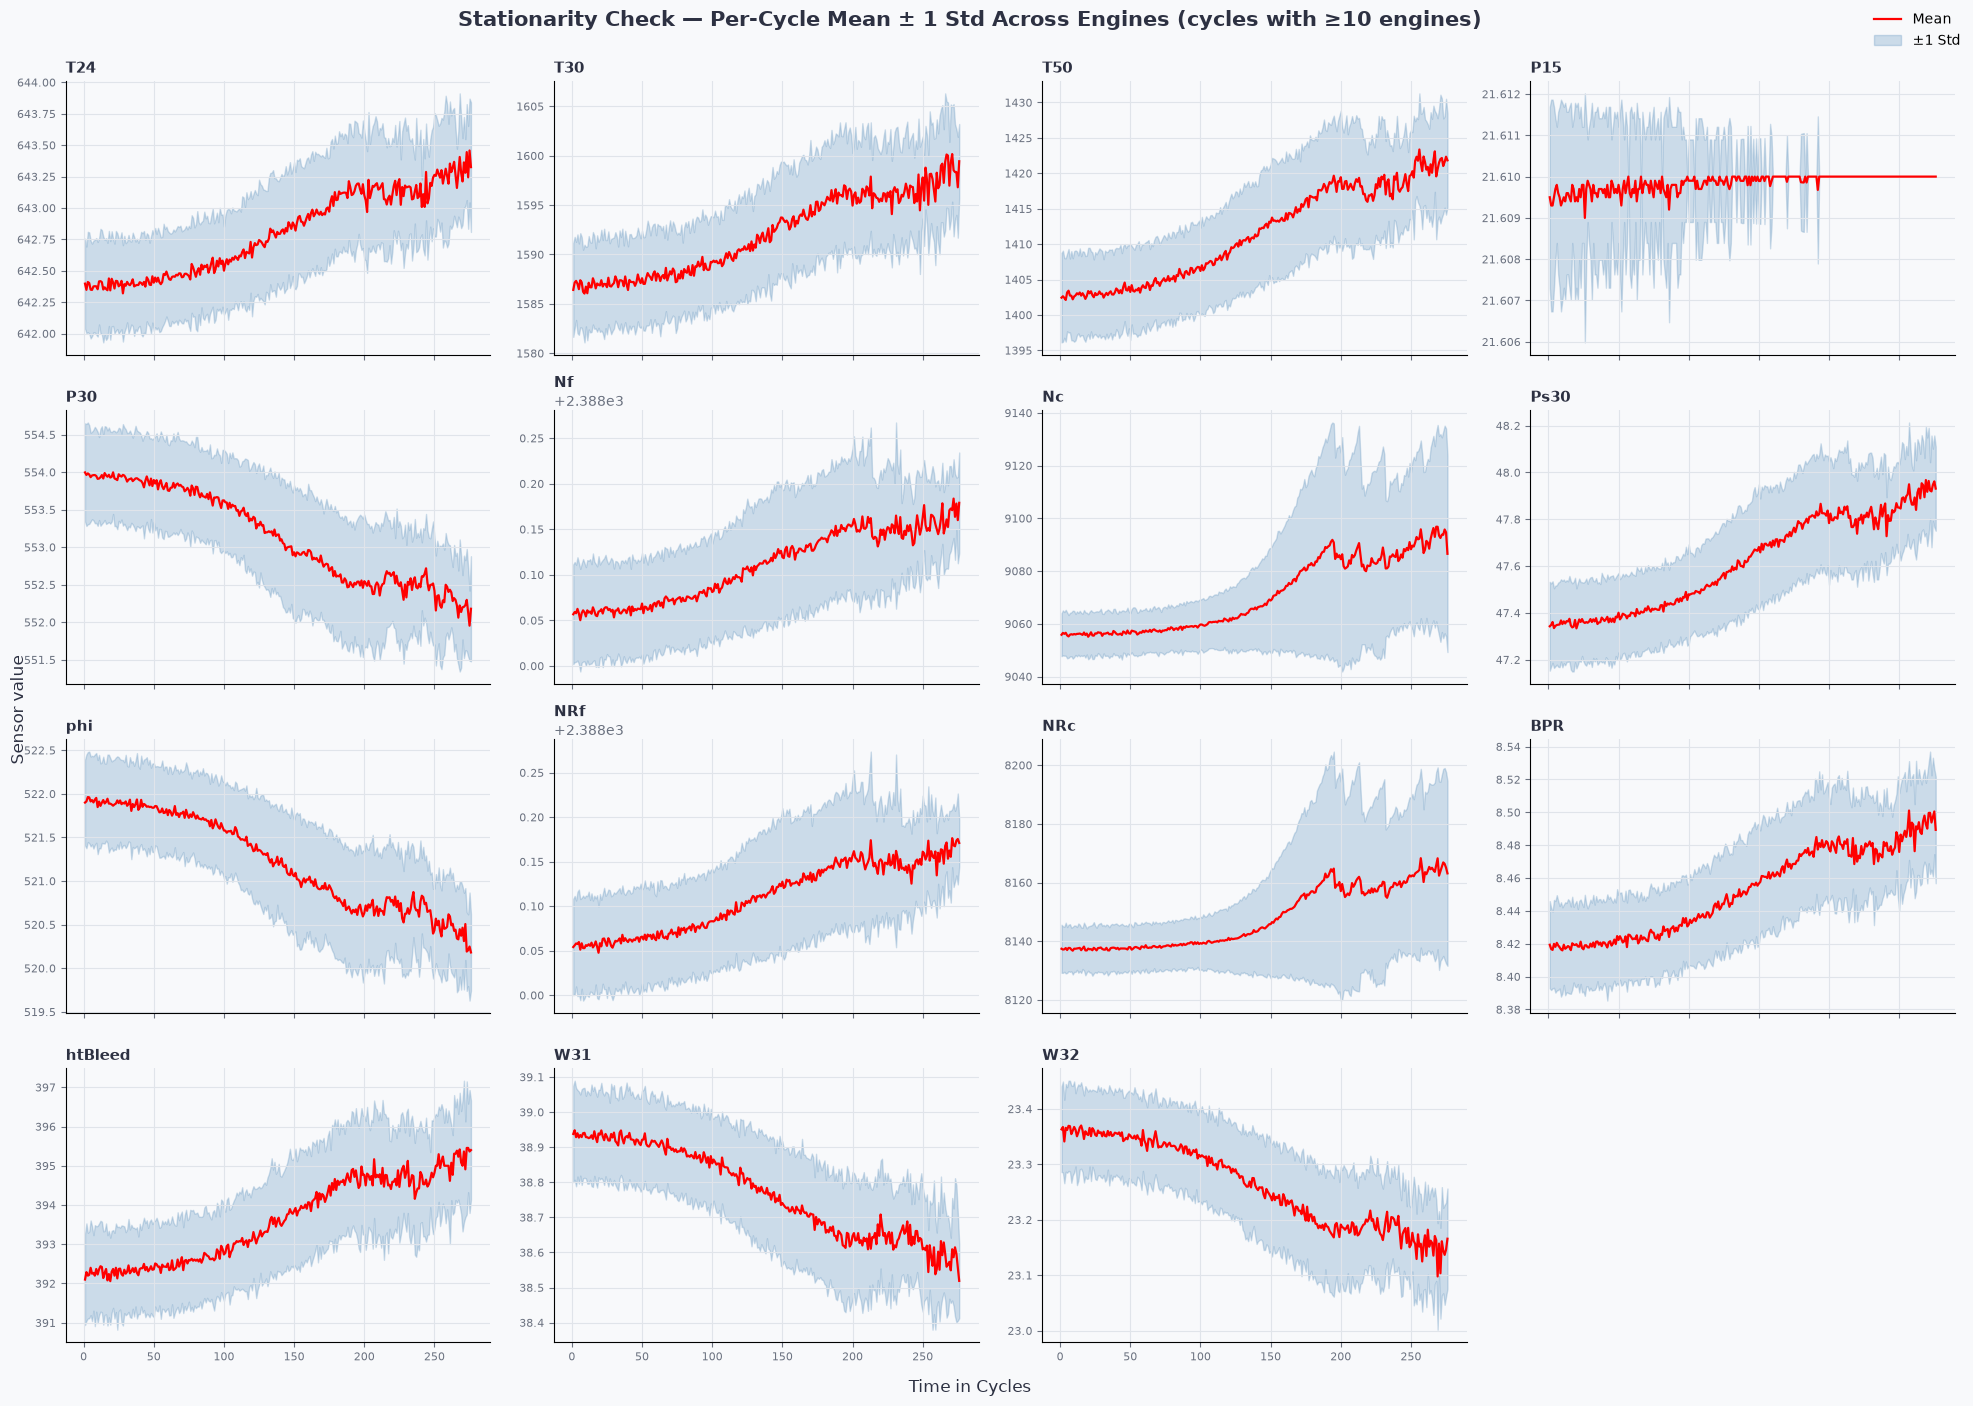

In [11]:
import math

# Stationarity Check
# Check whether sensor mean and variance remain stable over time (eyeball check)
# Per-cycle mean and std across all engines (cross-sectional, not a rolling window)

sensors = [col for col in df_train_clean.columns
           if col not in ['unit_number', 'time_in_cycles', 'RUL_Max', 'RUL', 'setting_1', 'setting_2']]

# Per-cycle stats computed once for all sensors
grouped   = df_train_clean.groupby('time_in_cycles')[sensors]
cyc_mean  = grouped.mean()
cyc_std   = grouped.std()
cyc_count = df_train_clean.groupby('time_in_cycles').size()

# Only show cycles with enough engines (threshold: 10)
# Late cycles have few surviving engines → std becomes unreliable
mask = cyc_count >= 10
cyc_mean, cyc_std = cyc_mean[mask], cyc_std[mask]

# Grid layout: 4 columns → 12 sensors = 3x4, 10 sensors = 3x4 with 2 empty panels
ncols = 4
nrows = math.ceil(len(sensors) / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(5 * ncols, 3.5 * nrows),
                         sharex=True)          # X shared; Y per-sensor since scales differ
fig.patch.set_facecolor('#F8F9FB')
axes = axes.flatten()

for ax, sensor in zip(axes, sensors):
    m, s = cyc_mean[sensor], cyc_std[sensor]

    ax.set_facecolor('#F8F9FB')
    # Mean line
    ax.plot(m.index, m.values, color='red', linewidth=1.6, label='Mean')
    # ±1 std band around the mean
    ax.fill_between(m.index, m - s, m + s,
                    alpha=0.25, color='steelblue', label='±1 Std')

    ax.set_title(sensor, fontsize=11, fontweight='bold', loc='left', color='#2D3142')
    ax.tick_params(colors='#6B7280', labelsize=8)
    ax.grid(True, color='#E0E4EA', linewidth=0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide unused axes when the sensor count doesn't fill the grid
for ax in axes[len(sensors):]:
    ax.set_visible(False)

# One shared legend + shared axis labels instead of repeating on every panel
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=10, framealpha=0)
fig.supxlabel('Time in Cycles', fontsize=12, color='#2D3142')
fig.supylabel('Sensor value', fontsize=12, color='#2D3142')
fig.suptitle('Stationarity Check — Per-Cycle Mean ± 1 Std Across Engines (cycles with ≥10 engines)',
             fontsize=15, fontweight='bold', color='#2D3142', y=1.0)

plt.tight_layout()
plt.show()

**Stationarity Check Results:**

What this shows: for each point in an engine's life, the average sensor reading (red) and how much engines differ from each other at that point (blue band = ±1 std). We use 1 std rather than 2 because the goal is to see the trend of the average, not to catch outliers — a wider band would bury the red line.

- Almost every sensor keeps drifting in one direction as engines age — same trends as above. Engines get more similar to each other over time, not less: the blue band stays roughly the same width.
- `P15` — flat line, band is just noise → carries no wear signal, removed.
- `Nc`, `NRc` (core speed) — the only two where the band opens up sharply after ~cycle 150: a few engines spike while the rest don't → unreliable, removed.
- So what: sensor levels change steadily with age, so the readings themselves tell us how worn an engine is — the model can learn directly from them.

## 3.4 Autocorrelation & Seasonality Check (Lag Plot)

Short  — Unit 39,  lifetime: 128
Medium — Unit 26, lifetime: 199
Long   — Unit 69,   lifetime: 362


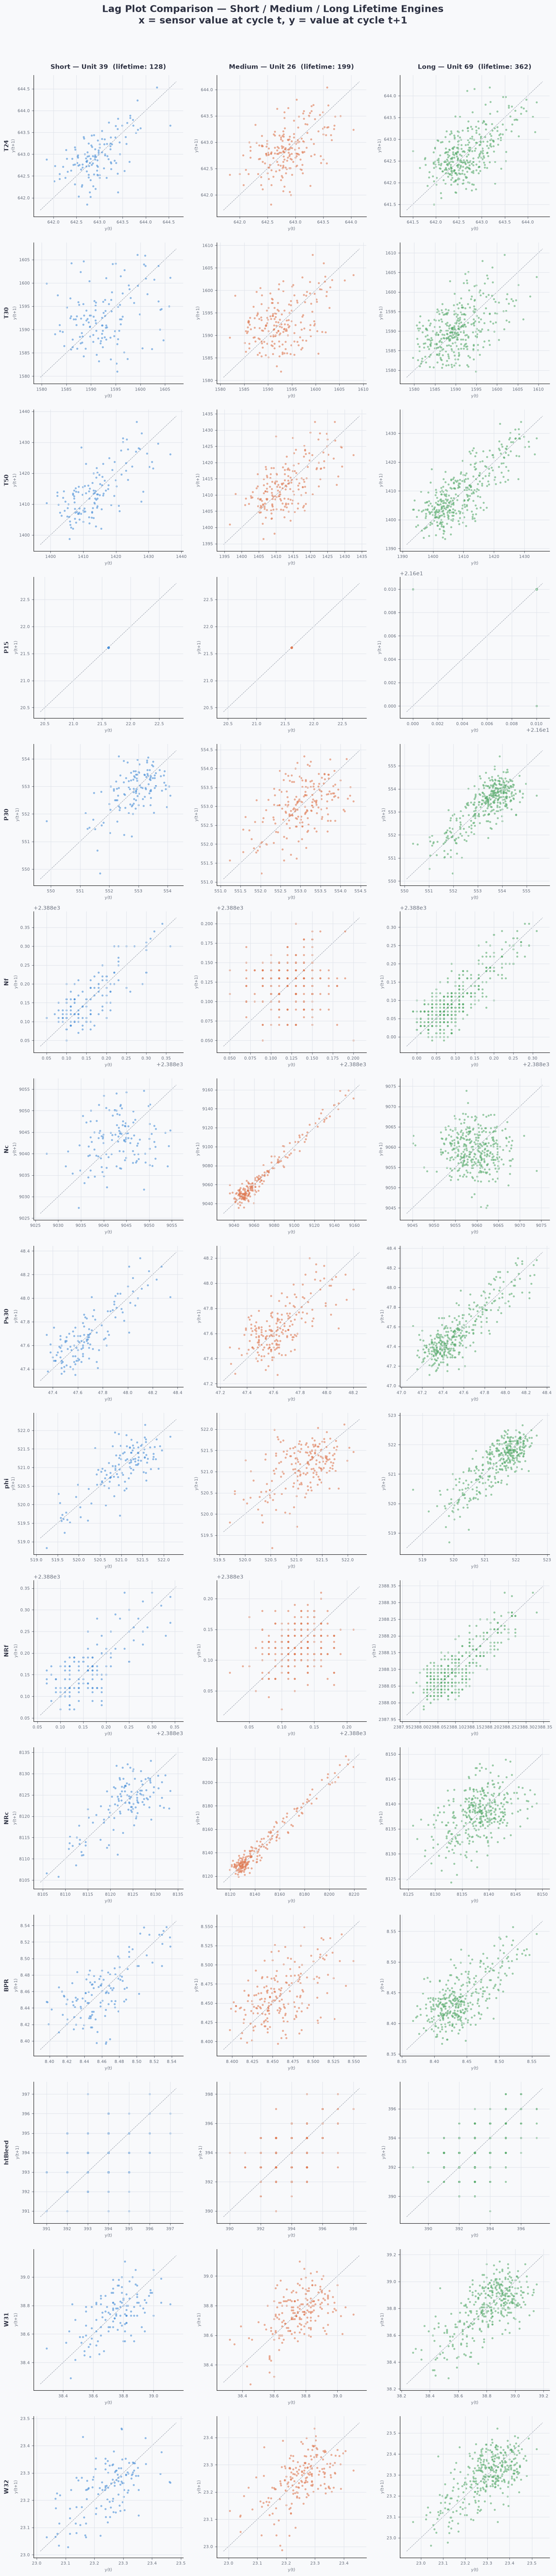

In [12]:
# Autocorrelation & Seasonality Check (Lag Plot)
# Compare short / medium / long lifetime engines to find consistent patterns

lifetimes = df_train_clean.groupby('unit_number')['time_in_cycles'].max()
median_lifetime = lifetimes.median()

short  = lifetimes.idxmin()
medium = (lifetimes - median_lifetime).abs().idxmin()
long   = lifetimes.idxmax()

print(f"Short  — Unit {short},  lifetime: {lifetimes[short]}")
print(f"Medium — Unit {medium}, lifetime: {lifetimes[medium]}")
print(f"Long   — Unit {long},   lifetime: {lifetimes[long]}")

sensors = [col for col in df_train_clean.columns
           if col not in ['unit_number', 'time_in_cycles', 'RUL_Max', 'RUL', 'setting_1', 'setting_2']]

units  = {'Short': short, 'Medium': medium, 'Long': long}
colors = {'Short': '#4A90D9', 'Medium': '#E07B54', 'Long': '#5BAD6F'}

num_rows = len(sensors)
num_cols = 3

fig, axes = plt.subplots(num_rows, num_cols,
                         figsize=(num_cols * 5, num_rows * 4.5),
                         squeeze=False)   # always 2D array, even with 1 row/col
fig.patch.set_facecolor('#F8F9FB')

for row, sensor in enumerate(sensors):
    for col, (label, unit) in enumerate(units.items()):
        ax = axes[row][col]
        unit_data = df_train_clean[df_train_clean['unit_number'] == unit]
        lag_plot(unit_data[sensor], ax=ax,
                 c=colors[label], alpha=0.5, s=8)

        # y = x reference line — points on the diagonal indicate autocorrelation
        lo, hi = ax.get_xlim()
        ax.plot([lo, hi], [lo, hi], color='#9CA3AF',
                linewidth=0.8, linestyle='--', zorder=0)

        ax.set_facecolor('#F8F9FB')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, color='#E0E4EA', linewidth=0.8)
        ax.tick_params(labelsize=8, colors='#6B7280')

        # Axis labels — keep them on every panel so y(t) vs y(t+1) is explicit
        ax.set_xlabel('y(t)',   fontsize=8, color='#6B7280')
        ax.set_ylabel('y(t+1)', fontsize=8, color='#6B7280')

        # Column header (only first row)
        if row == 0:
            ax.set_title(
                f'{label} — Unit {unit}  (lifetime: {lifetimes[unit]})',
                fontsize=12, fontweight='bold', color='#2D3142', pad=12
            )

        # Row header: sensor name placed outside the left edge (only first column)
        if col == 0:
            ax.annotate(sensor, xy=(0, 0.5), xycoords='axes fraction',
                        xytext=(-45, 0), textcoords='offset points',
                        ha='right', va='center', rotation=90,
                        fontsize=11, fontweight='bold', color='#2D3142')

fig.suptitle('Lag Plot Comparison — Short / Medium / Long Lifetime Engines\n'
             'x = sensor value at cycle t, y = value at cycle t+1',
             fontsize=18, fontweight='bold', color='#2D3142', y=1.0)
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.tight_layout(rect=[0.02, 0, 1, 0.99])
plt.show()

**Autocorrelation Check (Lag Plot) Results:**

Consistent autocorrelation across all three engines (retained):
- `T24`, `T30`, `T50`, `P30`, `Ps30`, `phi`, `W31`, `W32`, `BPR`, `Nf`, `NRf`, `htBleed`
  — diagonal pattern observed across short / medium / long lifetime engines
  (`Nf`, `NRf`, `htBleed` appear grid-like because they report discrete values, but still follow the diagonal)

Already removed — lag plot consistent with removal:
- `Nc`, `NRc` — shape changes across engine groups (loose cloud in short/long, tight diagonal in medium), driven by the late-cycle spike in some engines
- `P15` — near-zero variance across all engines

**Key Takeaways:**
- No loop or repeating shapes → no cyclic/seasonal pattern; expected, since engine cycles are not calendar time
- Strong autocorrelation in every retained sensor → each reading depends on the previous one, which is why sequential models (LSTM, GRU, CNN) are used instead of treating rows independently

## 3.5 Outlier Check

/var/folders/x5/vgqy2npj3xb4k9w4dfp1hdvc0000gn/T/ipykernel_54539/3602052808.py:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data, vert=True, patch_artist=True,
/var/folders/x5/vgqy2npj3xb4k9w4dfp1hdvc0000gn/T/ipykernel_54539/3602052808.py:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data, vert=True, patch_artist=True,
/var/folders/x5/vgqy2npj3xb4k9w4dfp1hdvc0000gn/T/ipykernel_54539/3602052808.py:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data, vert=True, patch_artist=True,
/var/folders/x5/vgqy2npj3xb4k9w4dfp1hdvc0000gn/T/ipykernel_54539/3602052808.py:19: MatplotlibDeprecationWarning: vert: bool was depre

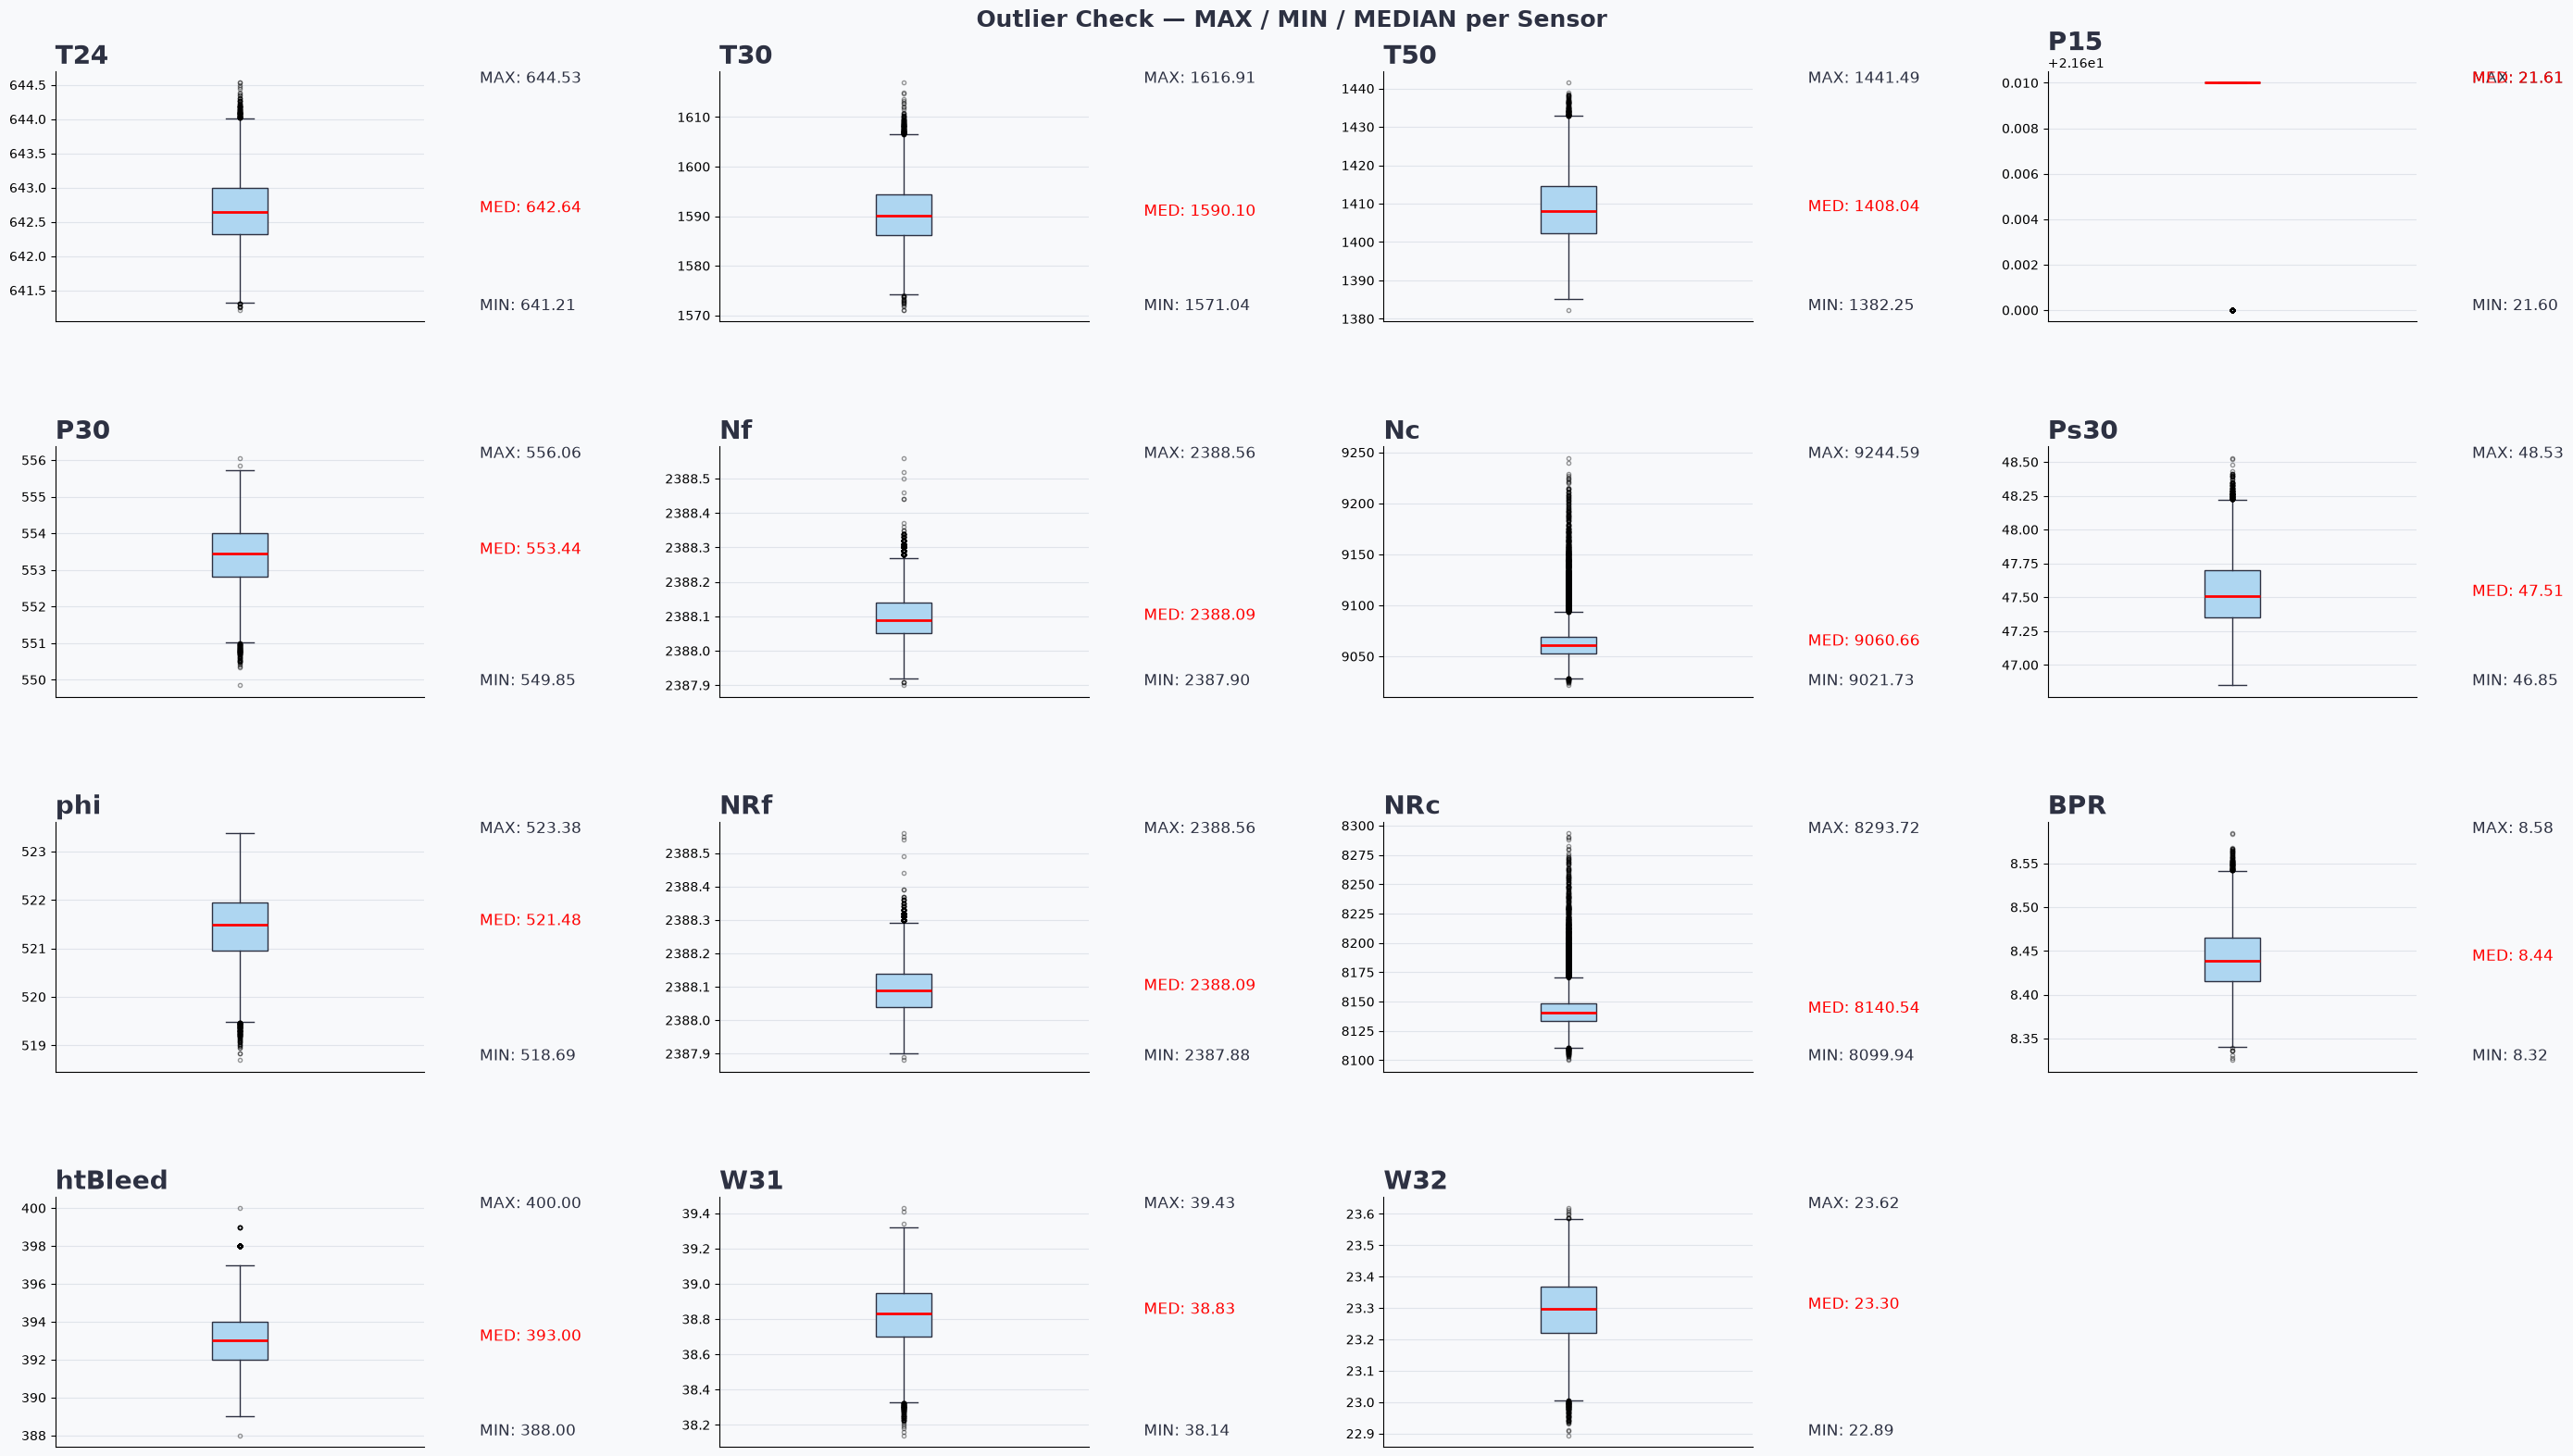

In [13]:
# Outlier Check
# Compare MAX, MIN, MEDIAN per sensor to detect outliers

sensors = [col for col in df_train_clean.columns
           if col not in ['unit_number', 'time_in_cycles', 'RUL_Max', 'RUL', 'setting_1', 'setting_2']]

num_cols = 4
num_rows = (len(sensors) + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols,
                         figsize=(num_cols * 7, num_rows * 4))
fig.patch.set_facecolor('#F8F9FB')
axes = axes.flatten()

for i, sensor in enumerate(sensors):
    ax = axes[i]
    data = df_train_clean[sensor]

    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='#AED6F1', color='#2D3142'),
               medianprops=dict(color='red', linewidth=2),
               whiskerprops=dict(color='#2D3142'),
               capprops=dict(color='#2D3142'),
               flierprops=dict(marker='o', color='#E07B54',
                               alpha=0.4, markersize=3))

    # Annotate MAX, MIN, MEDIAN
    ax.annotate(f'MAX: {data.max():.2f}',
                xy=(1.15, data.max()), xycoords=('axes fraction', 'data'),
                fontsize=12, color='#2D3142')
    ax.annotate(f'MIN: {data.min():.2f}',
                xy=(1.15, data.min()), xycoords=('axes fraction', 'data'),
                fontsize=12, color='#2D3142')
    ax.annotate(f'MED: {data.median():.2f}',
                xy=(1.15, data.median()), xycoords=('axes fraction', 'data'),
                fontsize=12, color='red')

    ax.set_title(sensor, fontsize=20, fontweight='bold',
                 loc='left', color='#2D3142')
    ax.set_facecolor('#F8F9FB')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, axis='y', color='#E0E4EA', linewidth=0.8)
    ax.set_xticks([])

for j in range(len(sensors), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Outlier Check — MAX / MIN / MEDIAN per Sensor',
             fontsize=18, fontweight='bold', color='#2D3142')
plt.tight_layout()
plt.subplots_adjust(hspace=0.5, wspace=0.8)
plt.show()

In [14]:
# Outlier Quantification
# Turn the boxplot impression into numbers: % of readings outside 1.5×IQR whiskers,
# and how far the most extreme value sits from the median (in IQR units; inf = constant sensor)

q1  = df_train_clean[sensors].quantile(0.25)
q3  = df_train_clean[sensors].quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

outlier_pct = ((df_train_clean[sensors] < lower) | (df_train_clean[sensors] > upper)).mean() * 100
max_dev_iqr = ((df_train_clean[sensors] - df_train_clean[sensors].median()).abs().max() / iqr)

summary = pd.DataFrame({'outlier_%': outlier_pct.round(2),
                        'max_dev_in_IQR': max_dev_iqr.round(1)}).sort_values('outlier_%', ascending=False)
summary

,outlier_%,max_dev_in_IQR
Nc,8.17,11.3
NRc,7.48,10.2
P15,1.97,inf
Nf,1.55,5.2
Ps30,0.81,2.9
T30,0.80,3.3
NRf,0.78,4.7
phi,0.71,2.8
W32,0.66,2.8
T24,0.62,2.8


**Outlier Check Results:**

Stable distributions with only mild tail outliers (retained):
- `T24`, `T30`, `T50`, `P30`, `phi`, `Ps30`, `W31`, `W32`, `BPR`
  — concentrated around the median, with some mild upper or lower tail points
- `htBleed`, `Nf`, `NRf` — discrete or very narrow-range sensors; the few tail points are within normal operating range, not anomalies

Features supporting removal:
- `P15` — near-constant values (MAX: 21.61, MIN: 21.60), indicating almost no discriminative signal
- `Nc`, `NRc` — long upper tails and frequent high-end outliers, supporting removal when combined with previous correlation and stationarity findings

**Key Takeaways:**
- Apart from the three sensors already flagged (`P15`, `Nc`, `NRc`), every sensor has an outlier rate of 2% or less, and even the most extreme readings stay close to the typical range.
- `Nc` and `NRc` are the clear exception at ~8% — about four times higher than any sensor we keep. `P15` shows `inf` in the table because it never changes.
- This also makes min-max scaling safe to use next — that method can be distorted by extreme values, but here there are too few to matter.
- The three removals decided earlier (`P15`, `Nc`, `NRc`) hold up under this check as well.

# 4. Preprocessing


In [15]:
# Drop sensors identified for removal during EDA
drop_cols = ['P15', 'Nc', 'NRc', 'setting_1', 'setting_2']

df_train_processed = df_train_clean.drop(columns=drop_cols)
df_test_processed  = df_test_clean.drop(columns=drop_cols)

print("Remaining features:", df_train_processed.shape[1])
print(df_train_processed.columns.tolist())

Remaining features: 16
['unit_number', 'time_in_cycles', 'T24', 'T30', 'T50', 'P30', 'Nf', 'Ps30', 'phi', 'NRf', 'BPR', 'htBleed', 'W31', 'W32', 'RUL_Max', 'RUL']


In [16]:
from sklearn.preprocessing import MinMaxScaler

# Columns to scale (exclude index and target variables)
scale_cols = ['T24', 'T30', 'T50', 'P30', 'Nf', 'Ps30', 'phi', 'NRf', 'BPR', 'htBleed', 'W31', 'W32']

scaler = MinMaxScaler()

# Fit on train, transform both train and test
df_train_processed[scale_cols] = scaler.fit_transform(df_train_processed[scale_cols])
df_test_processed[scale_cols]  = scaler.transform(df_test_processed[scale_cols])

df_train_processed.head()

,unit_number,time_in_cycles,T24,T30,T50,P30,Nf,Ps30,phi,NRf,BPR,htBleed,W31,W32,RUL_Max,RUL
0,1,1,0.183735,0.406802,0.309757,0.726248,0.242424,0.369048,0.633262,0.205882,0.363986,0.333333,0.713178,0.724662,192,191
1,1,2,0.283133,0.453019,0.352633,0.628019,0.212121,0.380952,0.765458,0.279412,0.411312,0.333333,0.666667,0.731014,192,190
2,1,3,0.343373,0.369523,0.370527,0.710145,0.272727,0.250000,0.795309,0.220588,0.357445,0.166667,0.627907,0.621375,192,189
3,1,4,0.343373,0.256159,0.331195,0.740741,0.318182,0.166667,0.889126,0.294118,0.166603,0.333333,0.573643,0.662386,192,188
4,1,5,0.349398,0.257467,0.404625,0.668277,0.242424,0.255952,0.746269,0.235294,0.402078,0.416667,0.589147,0.704502,192,187


**Preprocessing Steps:**

1. **Feature Removal**
   - Constant columns (near-zero variance): `TRA`, `Nf_dmd`, `PCNfR_dmd`, `farB`, `epr`, `P2`, `T2`
   - EDA-based removal: `P15` (no signal), `Nc`, `NRc` (unstable behavior + multicollinearity)
   - Low RUL correlation: `setting_1`, `setting_2`
   - Remaining sensors: `T24`, `T30`, `T50`, `P30`, `Nf`, `Ps30`, `phi`, `NRf`, `BPR`, `htBleed`, `W31`, `W32` (12 sensors)

2. **Min-Max Scaling**
   - Applied to all 12 sensor columns, scaling values to [0, 1] range
   - Why: sequence neural networks (LSTM / GRU / CNN) train more stably on bounded inputs, and sensor scales differ by orders of magnitude (T30 ≈ 1,590 vs BPR ≈ 8.4). Min-max's sensitivity to extremes is not an issue here — outlier check showed ≤2% outliers in every retained sensor.
   - XGBoost doesn't need scaling; scaled inputs used for all models for consistency (no effect on trees).
   - `fit_transform` on train set only; `transform` on test set with the train-fitted scaler — prevents data leakage

# 5. Modeling

**Model Selection**

Five models are compared — the most widely used approaches for RUL prediction:
- `XGBoost` — tabular baseline; each cycle treated as an independent row
- `LSTM`, `GRU` — sequence models that read cycles in order and keep memory of past values
- `1D CNN` — sequence model that detects short-range shape patterns
- `CNN-LSTM` — combines CNN pattern extraction with LSTM memory

Why this set: EDA showed strong autocorrelation and one-directional drift, so sequence models should beat the baseline. Comparing four architectures shows which way of reading a sequence fits this data best.

## 5.1 XGBoost

In [17]:
# Evaluation utilities
# Every model below reports through `record()`, so the comparison table in
# section 6 is built from the actual runs instead of numbers copied by hand.
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def nasa_score(y_true, y_pred):
    """PHM08 asymmetric score — predicting failure late costs more than early."""
    d = y_pred - y_true
    return np.sum(np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1))

metrics = {}   # model name -> {'RMSE': ..., 'MAE': ..., 'R2': ..., 'NASA Score': ...}

def record(name, y_true, y_pred):
    """Score a model, keep the result in `metrics`, and print it.

    Returns nothing on purpose — the numbers live in `metrics`, and a return
    value would render a duplicate repr under every evaluation cell.
    """
    metrics[name] = {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
        'NASA Score': nasa_score(y_true, y_pred),
    }
    print(name)
    for key, value in metrics[name].items():
        tail = "  (lower is better)" if key == 'NASA Score' else ""
        print(f"  {key:12s} {value:10.4f}{tail}")


In [18]:
# Feature Engineering for XGBoost
# XGBoost sees each row independently → fold recent history into rolling stats
# (sequence models read the raw window directly, so they skip this step)

# RUL cap — applies to the training target for ALL models (XGBoost and sequence models)
# Early-life RUL is large but sensors barely change → not learnable.
# Cap at 125 (standard in CMAPSS literature) so models focus on the degradation phase.
# Test targets are left uncapped — see note below.
RUL_CAP = 125
df_train_processed['RUL'] = df_train_processed['RUL'].clip(upper=RUL_CAP)

# 10-cycle window: smooths noise but still reacts to late-cycle changes
WINDOW_SIZE = 10

sensor_cols = ['T24', 'T30', 'T50', 'P30', 'Nf', 'Ps30', 'phi', 'NRf', 'BPR', 'htBleed', 'W31', 'W32']

def add_rolling_features(df, sensors, window):
    df = df.copy()
    for sensor in sensors:
        df[f'{sensor}_mean_{window}'] = (
            df.groupby('unit_number')[sensor]
            .transform(lambda x: x.rolling(window, min_periods=1).mean())
        )
        df[f'{sensor}_std_{window}'] = (
            df.groupby('unit_number')[sensor]
            .transform(lambda x: x.rolling(window, min_periods=1).std().fillna(0))
        )
        df[f'{sensor}_max_{window}'] = (
            df.groupby('unit_number')[sensor]
            .transform(lambda x: x.rolling(window, min_periods=1).max())
        )
    return df

df_train_fe = add_rolling_features(df_train_processed, sensor_cols, WINDOW_SIZE)
df_test_fe  = add_rolling_features(df_test_processed, sensor_cols, WINDOW_SIZE)

print(f"Features before: {len(sensor_cols)}  (raw sensors)")
print(f"Features after:  {len(sensor_cols) * 4}  (12 raw + 12×3 rolling mean/std/max)")

Features before: 12  (raw sensors)
Features after:  48  (12 raw + 12×3 rolling mean/std/max)


In [19]:
# XGBoost Modeling
from xgboost import XGBRegressor

# Define feature and target columns
exclude_cols = ['unit_number', 'time_in_cycles', 'RUL_Max', 'RUL']
feature_cols = [col for col in df_train_fe.columns if col not in exclude_cols]

X_train = df_train_fe[feature_cols]
y_train = df_train_fe['RUL']

# Use last cycle per engine for test evaluation
df_test_last = df_test_fe.groupby('unit_number').last().reset_index()
X_test = df_test_last[feature_cols]
y_test = df_test_last['RUL_Max']  # true RUL at last observed cycle

# Train model
model_xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=SEED,
    verbosity=0
)
model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)

In [20]:
# XGBoost Evaluation
record('XGBoost', y_test, y_pred_xgb)


XGBoost
  RMSE            19.8286
  MAE             14.7346
  R2               0.7723
  NASA Score    1305.1450  (lower is better)


## 5.2 LSTM

In [21]:
# LSTM Data Preparation
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Keep training output readable — TF's retracing notices are not actionable here
tf.get_logger().setLevel('ERROR')

WINDOW_SIZE_LSTM = 30

sensor_cols = ['T24', 'T30', 'T50', 'P30', 'Nf', 'Ps30', 'phi', 'NRf', 'BPR', 'htBleed', 'W31', 'W32']

def create_sequences(df, sensors, window, target='RUL'):
    X, y = [], []
    for unit in df['unit_number'].unique():
        unit_data = df[df['unit_number'] == unit].sort_values('time_in_cycles')
        sensor_data = unit_data[sensors].values
        target_data = unit_data[target].values

        for i in range(len(sensor_data) - window + 1):
            X.append(sensor_data[i:i+window])
            y.append(target_data[i+window-1])

    return np.array(X), np.array(y)

X_train_lstm, y_train_lstm = create_sequences(df_train_processed, sensor_cols, WINDOW_SIZE_LSTM)
print(f"X_train shape: {X_train_lstm.shape}")
print(f"y_train shape: {y_train_lstm.shape}")

X_train shape: (17731, 30, 12)
y_train shape: (17731,)


In [22]:
# LSTM Test Data Preparation
# For test: use last 30 cycles per engine
def create_test_sequences(df, sensors, window):
    X = []
    for unit in df['unit_number'].unique():
        unit_data = df[df['unit_number'] == unit].sort_values('time_in_cycles')
        sensor_data = unit_data[sensors].values
        # Take last `window` cycles
        if len(sensor_data) >= window:
            X.append(sensor_data[-window:])
        else:
            # Pad with zeros if engine life shorter than window
            pad = np.zeros((window - len(sensor_data), len(sensors)))
            X.append(np.vstack([pad, sensor_data]))
    return np.array(X)

X_test_lstm = create_test_sequences(df_test_processed, sensor_cols, WINDOW_SIZE_LSTM)
y_test_lstm = df_test_processed.groupby('unit_number')['RUL_Max'].last().values

print(f"X_test shape: {X_test_lstm.shape}")
print(f"y_test shape: {y_test_lstm.shape}")

X_test shape: (100, 30, 12)
y_test shape: (100,)


In [23]:
# LSTM Model
from tensorflow.keras.callbacks import EarlyStopping

# Seed weight init, dropout masks and batch shuffling for this model
tf.keras.utils.set_random_seed(SEED)

inputs = tf.keras.Input(shape=(WINDOW_SIZE_LSTM, len(sensor_cols)))
x = LSTM(64, return_sequences=True)(inputs)
x = Dropout(0.2)(x)
x = LSTM(32, return_sequences=False)(x)
x = Dropout(0.2)(x)
x = Dense(16, activation='relu')(x)
outputs = Dense(1)(x)

model_lstm = tf.keras.Model(inputs, outputs)

model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)
model_lstm.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model_lstm.fit(
    X_train_lstm, y_train_lstm,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    # one line per epoch — verbose=1 writes thousands of per-batch
    # progress frames into the saved notebook
    verbose=2
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 64)         │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,673 (127.63 KB)

 Trainable params: 32,673 (127.63 KB)

 Non-trainable params: 0 (0.00 B)

...

222/222 - 3s - 15ms/step - loss: 229.7041 - val_loss: 195.8788


Epoch 30/100


222/222 - 3s - 15ms/step - loss: 222.9115 - val_loss: 190.7486


Epoch 31/100


222/222 - 4s - 16ms/step - loss: 224.1282 - val_loss: 210.1741


In [24]:
# LSTM Evaluation
y_pred_lstm = model_lstm.predict(X_test_lstm, verbose=0).flatten()
record('LSTM', y_test_lstm, y_pred_lstm)


LSTM
  RMSE            15.3334
  MAE             12.0344
  R2               0.8639
  NASA Score     405.6972  (lower is better)


## 5.3 GRU

In [25]:
# GRU Model
from tensorflow.keras.layers import GRU

# Seed weight init, dropout masks and batch shuffling for this model
tf.keras.utils.set_random_seed(SEED)

inputs = tf.keras.Input(shape=(WINDOW_SIZE_LSTM, len(sensor_cols)))
x = GRU(64, return_sequences=True)(inputs)
x = Dropout(0.2)(x)
x = GRU(32, return_sequences=False)(x)
x = Dropout(0.2)(x)
x = Dense(16, activation='relu')(x)
outputs = Dense(1)(x)

model_gru = tf.keras.Model(inputs, outputs)

model_gru.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)
model_gru.summary()

early_stop_gru = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_gru = model_gru.fit(
    X_train_lstm, y_train_lstm,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop_gru],
    # one line per epoch — verbose=1 writes thousands of per-batch
    # progress frames into the saved notebook
    verbose=2
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 30, 64)         │        14,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,929 (97.38 KB)

 Trainable params: 24,929 (97.38 KB)

 Non-trainable params: 0 (0.00 B)

...

222/222 - 4s - 18ms/step - loss: 222.2767 - val_loss: 179.8786


Epoch 29/100


222/222 - 4s - 17ms/step - loss: 224.6223 - val_loss: 175.5240


Epoch 30/100


222/222 - 4s - 17ms/step - loss: 220.3549 - val_loss: 182.2560


In [26]:
# GRU Evaluation
y_pred_gru = model_gru.predict(X_test_lstm, verbose=0).flatten()
record('GRU', y_test_lstm, y_pred_gru)


GRU
  RMSE            15.0691
  MAE             11.4741
  R2               0.8685
  NASA Score     410.5817  (lower is better)


## 5.4 1D CNN

In [27]:
# 1D CNN Model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten

# Seed weight init, dropout masks and batch shuffling for this model
tf.keras.utils.set_random_seed(SEED)

inputs = tf.keras.Input(shape=(WINDOW_SIZE_LSTM, len(sensor_cols)))
x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(inputs)
x = Conv1D(32, kernel_size=3, activation='relu', padding='same')(x)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.2)(x)
x = Flatten()(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(1)(x)

model_cnn = tf.keras.Model(inputs, outputs)

model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)
model_cnn.summary()

early_stop_cnn = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_cnn = model_cnn.fit(
    X_train_lstm, y_train_lstm,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop_cnn],
    # one line per epoch — verbose=1 writes thousands of per-batch
    # progress frames into the saved notebook
    verbose=2
)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 30, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 30, 64)         │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 480)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │        15,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,969 (93.63 KB)

 Trainable params: 23,969 (93.63 KB)

 Non-trainable params: 0 (0.00 B)

...

222/222 - 1s - 3ms/step - loss: 334.2260 - val_loss: 205.2510


Epoch 37/100


222/222 - 1s - 3ms/step - loss: 334.1387 - val_loss: 211.3445


Epoch 38/100


222/222 - 1s - 3ms/step - loss: 333.5225 - val_loss: 200.8204


In [28]:
# 1D CNN Evaluation
y_pred_cnn = model_cnn.predict(X_test_lstm, verbose=0).flatten()
record('1D CNN', y_test_lstm, y_pred_cnn)


1D CNN
  RMSE            14.7591
  MAE             11.0028
  R2               0.8739
  NASA Score     369.4470  (lower is better)


## 5.5 CNN-LSTM

In [29]:
# CNN-LSTM Model
# Seed weight init, dropout masks and batch shuffling for this model
tf.keras.utils.set_random_seed(SEED)

inputs = tf.keras.Input(shape=(WINDOW_SIZE_LSTM, len(sensor_cols)))
x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(inputs)
x = Conv1D(32, kernel_size=3, activation='relu', padding='same')(x)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.2)(x)
x = LSTM(32, return_sequences=False)(x)
x = Dropout(0.2)(x)
x = Dense(16, activation='relu')(x)
outputs = Dense(1)(x)

model_cnn_lstm = tf.keras.Model(inputs, outputs)

model_cnn_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)
model_cnn_lstm.summary()

early_stop_cnn_lstm = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_cnn_lstm = model_cnn_lstm.fit(
    X_train_lstm, y_train_lstm,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop_cnn_lstm],
    # one line per epoch — verbose=1 writes thousands of per-batch
    # progress frames into the saved notebook
    verbose=2
)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 30, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 30, 64)         │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 30, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,409 (68.00 KB)

 Trainable params: 17,409 (68.00 KB)

 Non-trainable params: 0 (0.00 B)

...

222/222 - 1s - 6ms/step - loss: 218.9327 - val_loss: 198.0435


Epoch 34/100


222/222 - 1s - 7ms/step - loss: 212.4003 - val_loss: 200.5282


Epoch 35/100


222/222 - 1s - 6ms/step - loss: 213.4269 - val_loss: 203.2480


In [30]:
# CNN-LSTM Evaluation
y_pred_cnn_lstm = model_cnn_lstm.predict(X_test_lstm, verbose=0).flatten()
record('CNN-LSTM', y_test_lstm, y_pred_cnn_lstm)


CNN-LSTM
  RMSE            14.9813
  MAE             11.8317
  R2               0.8700
  NASA Score     388.2749  (lower is better)


# 6. Evaluation


In [31]:
# Model Comparison — assembled from the `metrics` collected above,
# so re-running the notebook updates this table automatically.
df_results = pd.DataFrame(metrics).T[['RMSE', 'MAE', 'R2', 'NASA Score']]
df_results.index.name = 'Model'
df_results.round(4)


,RMSE,MAE,R2,NASA Score
Model,,,,
XGBoost,19.8286,14.7346,0.7723,1305.1450
LSTM,15.3334,12.0344,0.8639,405.6972
GRU,15.0691,11.4741,0.8685,410.5817
1D CNN,14.7591,11.0028,0.8739,369.4470
CNN-LSTM,14.9813,11.8317,0.8700,388.2749


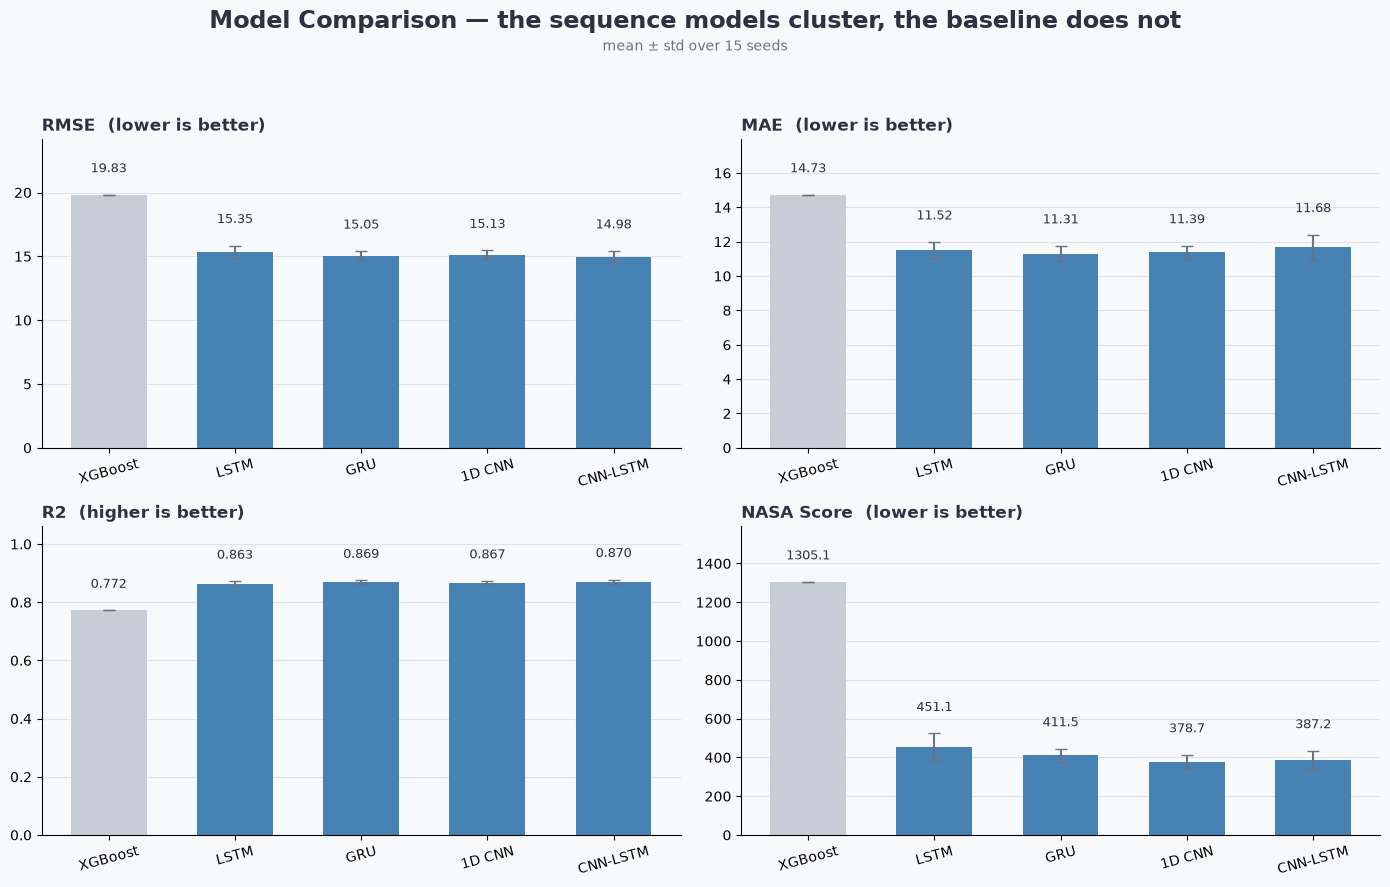

In [32]:
# Model Comparison — chart
# Bars show the mean across the seeds recorded in seed_study.csv, with error
# bars for the spread. The four sequence models are highlighted as one group
# rather than crowning a winner: across 15 seeds no pair of them separates under
# a paired test, so the real division here is sequence vs tabular. Each metric
# gets its own panel because the scales differ by orders of magnitude
# (R2 ~0.9 vs NASA Score ~1000).
from pathlib import Path

DIRECTION = {'RMSE': 'lower', 'MAE': 'lower', 'R2': 'higher', 'NASA Score': 'lower'}
ORDER = ['XGBoost', 'LSTM', 'GRU', '1D CNN', 'CNN-LSTM']

seed_csv = Path('seed_study.csv')
if seed_csv.exists():
    runs = pd.read_csv(seed_csv)
    grouped = runs.groupby('Model')[list(DIRECTION)]
    mean, err = grouped.mean().reindex(ORDER), grouped.std().reindex(ORDER)
    subtitle = f"mean \u00b1 std over {runs['seed'].nunique()} seeds"
else:
    mean, err = df_results.reindex(ORDER), None
    subtitle = f"single run (SEED={SEED}) — run seed_study.py to add error bars"

SEQUENCE = ['LSTM', 'GRU', '1D CNN', 'CNN-LSTM']
colors = ['steelblue' if m in SEQUENCE else '#C7CDD6' for m in mean.index]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.patch.set_facecolor('#F8F9FB')

for ax, (metric, direction) in zip(axes.flatten(), DIRECTION.items()):
    ax.set_facecolor('#F8F9FB')
    bars = ax.bar(mean.index, mean[metric], width=0.6, color=colors,
                  yerr=None if err is None else err[metric], capsize=4, ecolor='#6B7280')
    # Bars sit on a zero baseline, so close values look identical — label them.
    fmt = '{:.3f}' if metric == 'R2' else '{:.1f}' if metric == 'NASA Score' else '{:.2f}'
    ax.bar_label(bars, labels=[fmt.format(v) for v in mean[metric]],
                 padding=3 if err is None else 14, fontsize=9, color='#2D3142')
    ax.set_ylim(0, mean[metric].max() * 1.22)
    ax.set_title(f"{metric}  ({direction} is better)", fontsize=12,
                 fontweight='bold', loc='left', color='#2D3142')
    ax.grid(True, axis='y', color='#E0E4EA', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', labelrotation=15)

fig.suptitle('Model Comparison — the sequence models cluster, the baseline does not',
             fontsize=17, fontweight='bold', color='#2D3142')
fig.text(0.5, 0.935, subtitle, ha='center', fontsize=10, color='#6B7280')
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


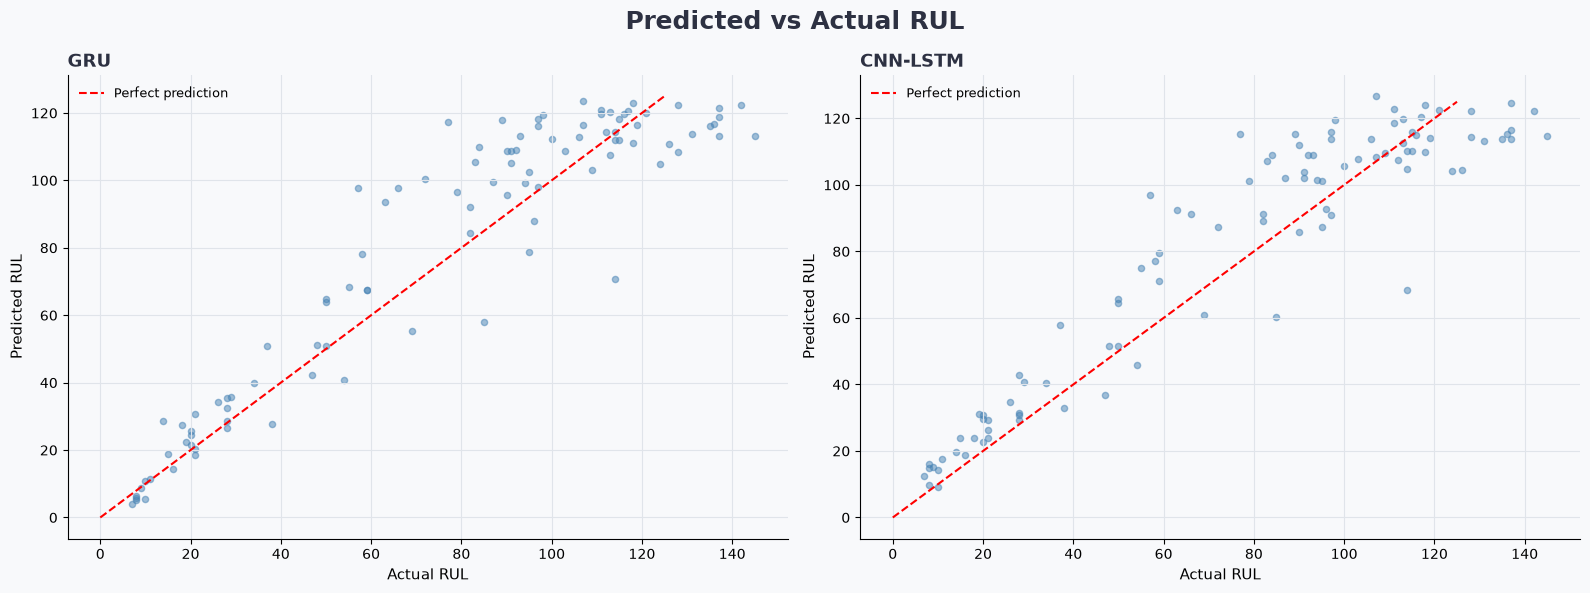

In [33]:
# Prediction vs Actual
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#F8F9FB')

# Best RMSE model: CNN-LSTM
for ax, (name, y_pred) in zip(axes, [('GRU', y_pred_gru), ('CNN-LSTM', y_pred_cnn_lstm)]):
    ax.set_facecolor('#F8F9FB')
    ax.scatter(y_test_lstm, y_pred, alpha=0.5, color='steelblue', s=20)
    ax.plot([0, 125], [0, 125], color='red', linewidth=1.5, linestyle='--', label='Perfect prediction')
    ax.set_xlabel('Actual RUL', fontsize=11)
    ax.set_ylabel('Predicted RUL', fontsize=11)
    ax.set_title(name, fontsize=13, fontweight='bold', loc='left', color='#2D3142')
    ax.legend(fontsize=9, framealpha=0)
    ax.grid(True, color='#E0E4EA', linewidth=0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Predicted vs Actual RUL', fontsize=18, fontweight='bold', color='#2D3142')
plt.tight_layout()
plt.show()

**Model Comparison:**

Mean ± standard deviation over 15 seeds (42–56), produced by `seed_study.py`.
The single-seed run above is one draw from these distributions — and a good
illustration of the problem: at `SEED = 42` the 1D CNN posts the best RMSE
(14.76), while averaged over 15 seeds CNN-LSTM edges ahead (14.98 vs 15.13) —
though a paired test across those seeds separates the two from neither each
other nor the rest.
The chart is highlighted from the three-seed means, not from the single run.
Bold marks the best mean *within each column*; it is not an overall ranking,
and no model leads on all four metrics.

| Model | RMSE | MAE | R² | NASA Score |
|---|---|---|---|---|
| XGBoost | 19.83 ± 0.00 | 14.73 ± 0.00 | 0.772 | 1305.1 |
| LSTM | 15.35 ± 0.50 | 11.52 ± 0.46 | 0.863 | 451.1 |
| GRU | 15.05 ± 0.36 | 11.31 ± 0.45 | 0.869 | 411.5 |
| 1D CNN | 15.13 ± 0.34 | 11.39 ± 0.38 | 0.867 | 378.7 |
| CNN-LSTM | 14.98 ± 0.45 | 11.68 ± 0.73 | 0.870 | 387.2 |

**Key Takeaways:**
- **The four sequence models are not separable, and more runs do not separate them.** Their means span 14.98–15.35 RMSE while individual runs swing by half a cycle. A paired comparison across the 15 seeds puts CNN-LSTM against GRU at t = 0.57, against 1D CNN at t = 0.99 and against LSTM at t = 2.12 — none of them reaching the 2.14 that 15 runs would require. CNN-LSTM has the lowest mean RMSE and R²; 1D CNN takes NASA Score, GRU takes MAE. Naming a winner would be reporting the seed.
- **The XGBoost gap is real.** At 19.83 RMSE it sits ~4.8 above every sequence model, with zero seed variance (tree building is deterministic once seeded). This is far outside the noise band and is the one ranking the experiment actually establishes: temporal context carries most of the RUL signal, and rolling-window summaries do not substitute for it.
- **Cost differs where accuracy does not.** 1D CNN trained in 16–29 s per seed versus 96–162 s for LSTM and GRU. Given indistinguishable accuracy, that is a real basis for choosing between them — unlike the RMSE decimals.
- GRU is the steadiest across seeds (RMSE ±0.04); LSTM the least (±0.61), so an LSTM result from a single run should be treated with the most caution.
- Note: during training, any remaining life above 125 cycles was treated as "125 — plenty of life left," since engines look identical that early on. The test set, however, is scored against each engine's true remaining life. So for the handful of test engines with more than 125 cycles left, the model can only say "about 125" and is counted as slightly off. The reported numbers are therefore a bit conservative.


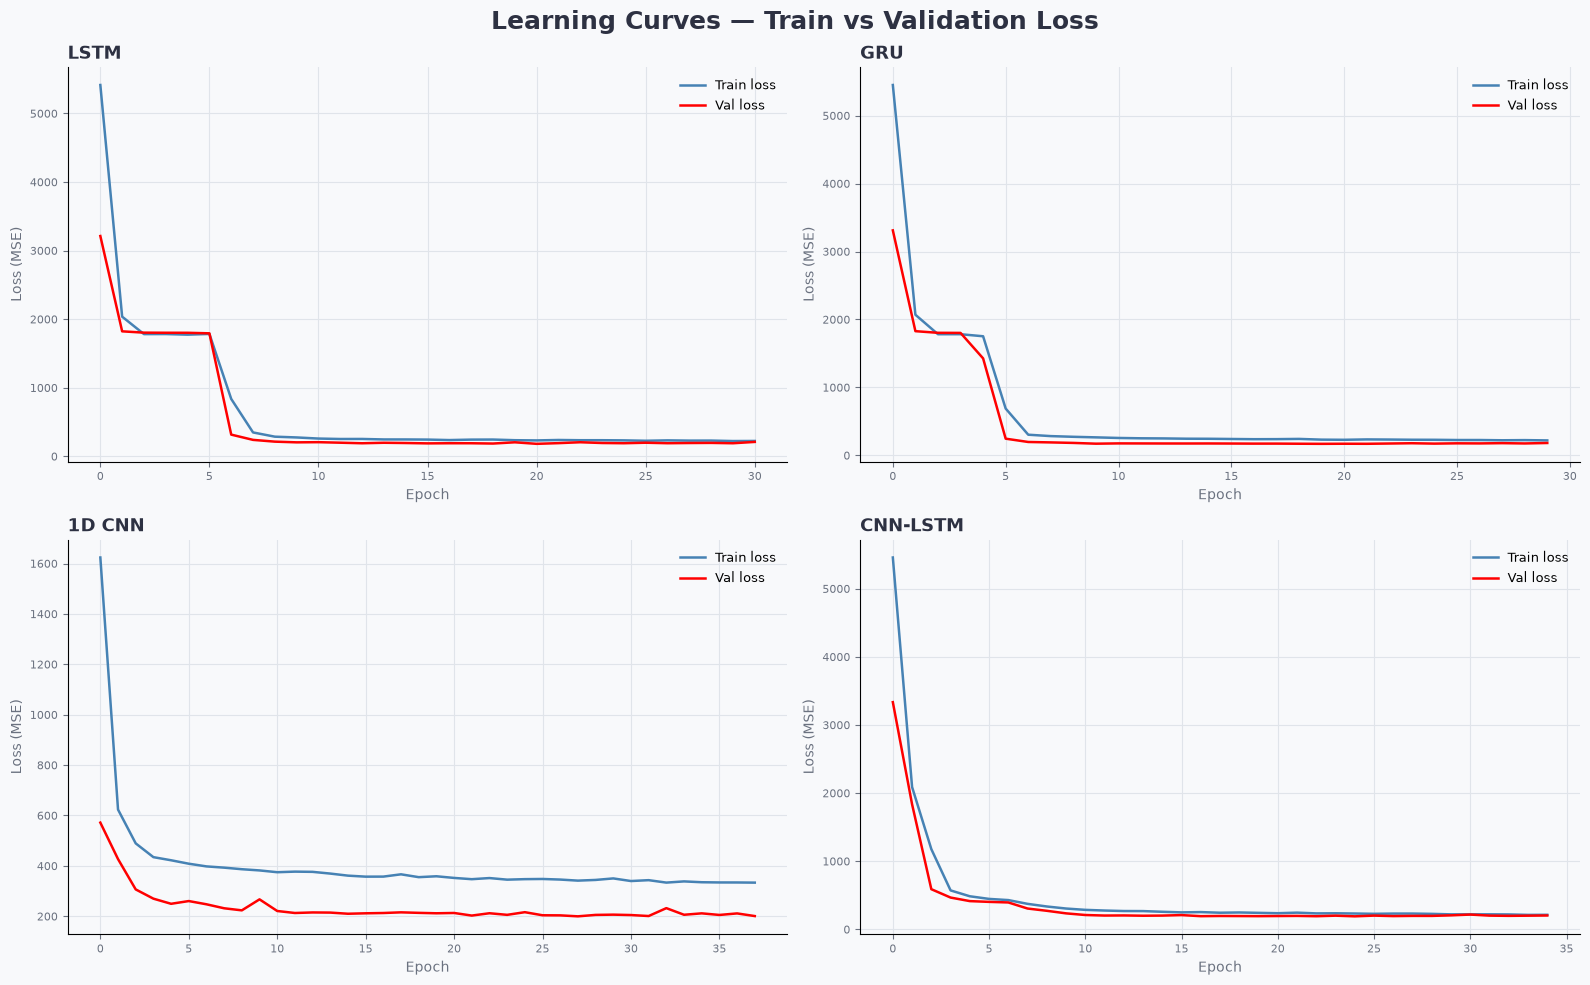

In [34]:
# Learning Curve Visualization
# Compare train loss vs val loss across all deep learning models

histories = {
    'LSTM': history,
    'GRU': history_gru,
    '1D CNN': history_cnn,
    'CNN-LSTM': history_cnn_lstm
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('#F8F9FB')
axes = axes.flatten()

for i, (name, hist) in enumerate(histories.items()):
    ax = axes[i]
    ax.set_facecolor('#F8F9FB')

    ax.plot(hist.history['loss'], color='steelblue', linewidth=1.8, label='Train loss')
    ax.plot(hist.history['val_loss'], color='red', linewidth=1.8, label='Val loss')

    ax.set_title(name, fontsize=13, fontweight='bold', loc='left', color='#2D3142')
    ax.set_xlabel('Epoch', fontsize=10, color='#6B7280')
    ax.set_ylabel('Loss (MSE)', fontsize=10, color='#6B7280')
    ax.legend(fontsize=9, framealpha=0)
    ax.grid(True, color='#E0E4EA', linewidth=0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(colors='#6B7280', labelsize=8)

fig.suptitle('Learning Curves — Train vs Validation Loss',
             fontsize=18, fontweight='bold', color='#2D3142')
plt.tight_layout()
plt.show()

**Learning Curve Analysis:**

Curves below are from the seeded run (`SEED = 42`); epoch counts vary because
early stopping halts each model on its own schedule.

- **LSTM** (31 epochs) — drops steeply, then sits on a plateau near MSE 1800 from about epoch 2 to 5 before falling again to ~250 and flattening. That plateau is the model parked on a near-constant prediction before it starts using the sequence; train and validation move together throughout.

- **GRU** (30 epochs) — same two-stage shape as LSTM but escapes the plateau a little earlier (~epoch 5). Train and validation curves are the most tightly aligned of the four, matching its low seed-to-seed variance (RMSE ±0.04).

- **1D CNN** (38 epochs) — no plateau; a smooth monotone decay instead. Validation loss sits *below* train loss for the entire run, which is the expected dropout artifact (dropout is active while training, off during evaluation). Its train loss settles around 340 versus ~200–250 for the recurrent models, indicating mild underfitting — yet it still scored the best RMSE at this seed, so the extra capacity of the recurrent models is not buying accuracy here.

- **CNN-LSTM** (35 epochs) — fastest clean convergence: no plateau, essentially flat by epoch 10, with train and validation closely aligned.

**Overall:** no model shows overfitting — validation loss never turns upward. The recurrent pair (LSTM, GRU) share a plateau-then-escape pattern that the convolutional pair does not, but all four converge to a similar loss floor, which is consistent with the seed study finding that their final scores are not meaningfully different.


# 7. Summary & Conclusion


**Project Goal:**  
Predict how many flight cycles a jet engine has left before it fails, using its sensor readings — so maintenance can be scheduled ahead of time instead of after a breakdown.

---

**Process Summary:**

1. **Data & Target**
   - NASA C-MAPSS FD001: 100 engines run from healthy to failure, 21 sensors per cycle.
   - Target = remaining cycles to failure (RUL), capped at 125 — early in life engines look identical, so only the wear-down phase is learnable.

2. **What the data showed (EDA)**
   - As engines age, temperatures rise while pressures and fuel flow fall — matching the compressor wear the dataset simulates.
   - Each reading depends strongly on the previous one → models should read sequences, not single snapshots.
   - Outliers are rare (≤2% per sensor); three sensors dropped for carrying no usable signal.

3. **Preparation**
   - 12 sensors kept; all scaled to a 0–1 range so no sensor dominates by size alone.
   - Scaling learned from training data only, then applied to test — no peeking at test data.

4. **Models**
   - Five approaches common in RUL work: `XGBoost` (baseline, sees one cycle at a time) and four sequence models — `LSTM`, `GRU`, `1D CNN`, `CNN-LSTM`.
   - XGBoost got 10-cycle rolling stats to stand in for history; sequence models read 30-cycle windows directly.

5. **Evaluation**
   - RMSE, MAE, R², and the NASA score (penalizes predicting "more life left" than there is).

---

**Final Model Comparison:**

*Mean ± std over 15 seeds (42–56) — see `seed_study.py`.*

| Model | RMSE | MAE | R² | NASA Score |
|---|---|---|---|---|
| XGBoost | 19.83 ± 0.00 | 14.73 ± 0.00 | 0.772 | 1305.1 |
| LSTM | 15.35 ± 0.50 | 11.52 ± 0.46 | 0.863 | 451.1 |
| GRU | 15.05 ± 0.36 | 11.31 ± 0.45 | 0.869 | 411.5 |
| 1D CNN | 15.13 ± 0.34 | 11.39 ± 0.38 | 0.867 | 378.7 |
| CNN-LSTM | 14.98 ± 0.45 | 11.68 ± 0.73 | 0.870 | 387.2 |

**Model choice:** the four sequence models are statistically tied over 15 seeds, so this notebook treats CNN-LSTM as the reference model — lowest mean RMSE (14.98) and R² (0.870) — rather than the winner. Predictions land within roughly 15 cycles of the truth. The honest caveat is that its margin over 1D CNN (0.12 RMSE) is smaller than the seed-to-seed spread, and 1D CNN wins MAE and NASA Score, so the four sequence models should be read as a tie. If training cost matters, 1D CNN reaches the same accuracy 4–6× faster.

What the experiment *does* establish is the gap between sequence models and the tabular baseline: ~15 RMSE versus 19.83, consistent across every seed. The *trend* in sensor readings, not just their level, is what predicts remaining life.

---

**Limitations & Next Steps:**
- Tested on one operating condition and one fault type (FD001) — broader datasets untested.
- Three seeds bound the noise but do not resolve the sequence models against each other; separating them would need more seeds, or a held-out engine split repeated across folds.
- The validation split is the last 20% of the sequence array, which corresponds to engines 82–100 rather than a random sample — a grouped, shuffled split would be a cleaner check.
- Hyperparameters not fully tuned; ensembling not tried.

# 8. Sensor Importance Cross-Check

In [35]:
# CNN-LSTM predicts well but can't tell us WHICH sensors drive the prediction.
# Fit two interpretable models on the same 12 scaled sensors (per-row, no sequence)
# and see whether their sensor rankings agree with each other and with the EDA trends.

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

X_imp = df_train_processed[sensor_cols]
y_imp = df_train_processed['RUL']          # capped at 125, same target as all models

# Random Forest — impurity-based feature importance
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=SEED, n_jobs=-1)
rf.fit(X_imp, y_imp)
rf_imp = pd.Series(rf.feature_importances_, index=sensor_cols)

# Linear regression — coefficient size (inputs are all 0–1, so coefficients are comparable)
lr = LinearRegression()
lr.fit(X_imp, y_imp)
lr_coef = pd.Series(lr.coef_, index=sensor_cols)

importance = pd.DataFrame({
    'RF importance': rf_imp.round(3),
    'RF rank': rf_imp.rank(ascending=False).astype(int),
    'LR coef': lr_coef.round(1),
    'LR |coef| rank': lr_coef.abs().rank(ascending=False).astype(int),
}).sort_values('RF importance', ascending=False)

importance

,RF importance,RF rank,LR coef,LR |coef| rank
Ps30,0.692,1,-51.0,1
T50,0.119,2,-43.3,4
phi,0.031,3,31.4,7
BPR,0.030,4,-35.2,5
W32,0.023,5,27.9,10
P30,0.021,6,30.7,8
T30,0.020,7,-27.3,11
T24,0.017,8,-24.0,12
W31,0.015,9,28.6,9
Nf,0.011,11,46.3,2


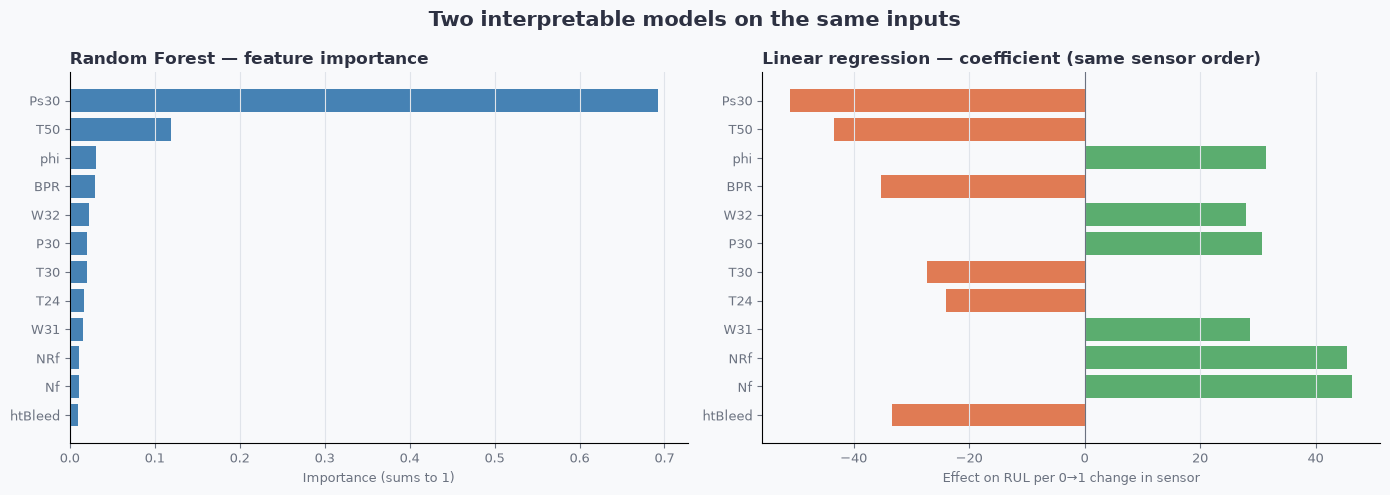

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#F8F9FB')

# Random Forest
rf_sorted = rf_imp.sort_values()
axes[0].barh(rf_sorted.index, rf_sorted.values, color='steelblue')
axes[0].set_title('Random Forest — feature importance', fontsize=12, fontweight='bold', loc='left', color='#2D3142')
axes[0].set_xlabel('Importance (sums to 1)', fontsize=9, color='#6B7280')

# Linear regression — sign shows direction: negative = higher value → less life left
lr_sorted = lr_coef.reindex(rf_sorted.index)
colors = ['#E07B54' if c < 0 else '#5BAD6F' for c in lr_sorted.values]
axes[1].barh(lr_sorted.index, lr_sorted.values, color=colors)
axes[1].axvline(0, color='#6B7280', linewidth=0.8)
axes[1].set_title('Linear regression — coefficient (same sensor order)', fontsize=12, fontweight='bold', loc='left', color='#2D3142')
axes[1].set_xlabel('Effect on RUL per 0→1 change in sensor', fontsize=9, color='#6B7280')

for ax in axes:
    ax.set_facecolor('#F8F9FB')
    ax.grid(True, axis='x', color='#E0E4EA', linewidth=0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(colors='#6B7280', labelsize=9)

fig.suptitle('Two interpretable models on the same inputs',
             fontsize=15, fontweight='bold', color='#2D3142')
plt.tight_layout()
plt.show()

**Sensor Importance Cross-Check:**

Two simple, transparent models were fit on the same 12 sensors to see *which* sensors matter — something the final CNN-LSTM can't show on its own.

- **Direction agrees everywhere.** Sensors that rise with age (`Ps30`, `T50`, `T30`, `T24`, `BPR`, `htBleed`) all get negative coefficients — higher reading, less life left. Sensors that fall (`phi`, `P30`, `W31`, `W32`) all get positive ones. All 12 match the EDA trends.
- **Ranking: `Ps30` dominates.** Random Forest gives `Ps30` 0.69 of total importance, then `T50` (0.12); the rest add little because they overlap with `Ps30`. `Ps30` measures pressure right after the high-pressure compressor — the very part FD001 simulates wearing out — so it makes sense that it reacts first and strongest.
- **Why the rankings differ.** Random Forest counts how often a sensor is actually used, so one strong sensor (`Ps30`) crowds out the ones that move with it. Linear regression tries to separate each sensor's effect, which gets shaky when sensors move together — `Nf`/`NRf` end up over-weighted. So we trust Random Forest for ranking and use regression only to confirm direction.
- **So what:** the two see-through models agree on which sensors matter and in which direction, and it matches the physics — good reason to believe the CNN-LSTM is learning real wear, not noise.